# Roll Rate Model V2 - With Model Evaluation

Complete workflow with evaluation charts for management presentation

In [1]:
import sys
from pathlib import Path
project_root = Path('.').resolve().parent
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

import pandas as pd
import numpy as np
from datetime import datetime
import matplotlib.pyplot as plt
import seaborn as sns

from src.config import CFG, BUCKETS_CANON, BUCKETS_30P, BUCKETS_90P
from src.config import parse_date_column, create_segment_columns, SEGMENT_COLS
from src.data_loader import load_data
from src.rollrate.transition import compute_transition_by_mob
from src.rollrate.lifecycle import *
from src.rollrate.calibration_kmob import fit_k_raw, smooth_k, fit_alpha, forecast_all_vintages_partial_step
from src.rollrate.lifecycle_export_enhanced import export_lifecycle_with_config_info

print('Import OK')

Import OK


## 1. LOAD DATA

In [ ]:
DATA_PATH = 'C:/Users/User/Projection_PB/Projection_pb/POS_Parquet_YYYYMM'
MAX_MOB = 24
TARGET_MOBS = [12]

df_raw = load_data(DATA_PATH)
df_raw['DISBURSAL_DATE'] = parse_date_column(df_raw['DISBURSAL_DATE'])
df_raw = create_segment_columns(df_raw)
print(f'Data: {len(df_raw):,} rows')

📦 Loading Parquet from: C:\Users\User\Projection_PB\Projection_pb\ETB_Parquet_YYYYMM
✅ Loaded 6,065,817 rows via pyarrow.dataset from C:\Users\User\Projection_PB\Projection_pb\ETB_Parquet_YYYYMM
Data: 6,065,817 rows


## 2. BUILD TRANSITION MATRICES

In [3]:
matrices_by_mob, parent_fallback = compute_transition_by_mob(df_raw)
print(f'{len(matrices_by_mob)} products')

⚠️ Có 4 hàng có tổng weight = 0: ['DPD120+', 'DPD180+', 'PREPAY', 'SOLDOUT']
⚙️ Built parent fallback for (product=T, score=A)
⚠️ Có 4 hàng có tổng weight = 0: ['DPD120+', 'DPD180+', 'PREPAY', 'SOLDOUT']
⚙️ Built parent fallback for (product=T, score=B)
⚠️ Có 4 hàng có tổng weight = 0: ['DPD120+', 'DPD180+', 'PREPAY', 'SOLDOUT']
⚙️ Built parent fallback for (product=T, score=C)
⚠️ Có 4 hàng có tổng weight = 0: ['DPD120+', 'DPD180+', 'PREPAY', 'SOLDOUT']
⚙️ Built parent fallback for (product=T, score=D)
⚠️ Có 4 hàng có tổng weight = 0: ['DPD120+', 'DPD180+', 'PREPAY', 'SOLDOUT']
⚙️ Built parent fallback for (product=T, score=NA)
⚠️ Có 4 hàng có tổng weight = 0: ['DPD120+', 'DPD180+', 'PREPAY', 'SOLDOUT']
⚙️ Built parent fallback for (product=X, score=A)
⚠️ Có 4 hàng có tổng weight = 0: ['DPD120+', 'DPD180+', 'PREPAY', 'SOLDOUT']
⚙️ Built parent fallback for (product=X, score=B)
⚠️ Có 4 hàng có tổng weight = 0: ['DPD120+', 'DPD180+', 'PREPAY', 'SOLDOUT']
⚙️ Built parent fallback for (pro

## 3. CALIBRATION

In [4]:
actual_results = get_actual_all_vintages_amount(df_raw)
loan_disb = df_raw.groupby(['PRODUCT_TYPE', 'RISK_SCORE', CFG['orig_date'], CFG['loan']])[CFG['disb']].first()
disb_total_by_vintage = loan_disb.groupby(level=[0, 1, 2]).sum().to_dict()

k_raw_by_mob, weight_by_mob, _ = fit_k_raw(
    actual_results=actual_results, matrices_by_mob=matrices_by_mob,
    parent_fallback=parent_fallback, states=BUCKETS_CANON, s30_states=BUCKETS_30P,
    include_co=True, denom_mode='disb', disb_total_by_vintage=disb_total_by_vintage,
    weight_mode='equal', method='wls_reg', lambda_k=1e-4, k_prior=0.0,
    min_obs=5, fallback_k=1.0, fallback_weight=0.0, return_detail=True)

mob_min = min(k_raw_by_mob.keys()) if k_raw_by_mob else 0
mob_max = max(k_raw_by_mob.keys()) if k_raw_by_mob else 0
k_smooth_by_mob, _, _ = smooth_k(k_raw_by_mob, weight_by_mob, mob_min, mob_max)

alpha, k_final_by_mob, _ = fit_alpha(
    actual_results=actual_results, matrices_by_mob=matrices_by_mob,
    parent_fallback=parent_fallback, states=BUCKETS_CANON, s30_states=BUCKETS_30P,
    k_smooth_by_mob=k_smooth_by_mob, mob_target=min(MAX_MOB, mob_max), include_co=True)

print(f'Alpha: {alpha:.4f}, K values: {len(k_final_by_mob)} MOBs')

# DEBUG: In ra K values để kiểm tra
k_final_values = list(k_final_by_mob.values())
print(f'\nK_final statistics:')
print(f'  Min: {min(k_final_values):.4f}')
print(f'  Max: {max(k_final_values):.4f}')
print(f'  Mean: {np.mean(k_final_values):.4f}')
print(f'\nK_raw statistics:')
k_raw_values = list(k_raw_by_mob.values())
print(f'  Min: {min(k_raw_values):.4f}')
print(f'  Max: {max(k_raw_values):.4f}')
print(f'  Mean: {np.mean(k_raw_values):.4f}')
print(f'\nNếu K > 1: Model under-estimates risk → K scale UP forecast')
print(f'Nếu K < 1: Model over-estimates risk → K scale DOWN forecast')
print(f'\n⚠️ K được clip trong [0, 1], nên K không thể > 1!')
print(f'Nếu K < 1, Forecast (With K) phải THẤP hơn Forecast (No K)')

C:\Users\User\Projection_PB\Projection_pb\src\rollrate\lifecycle.py:853: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_m.groupby(state_col)[ead_col].sum()
C:\Users\User\Projection_PB\Projection_pb\src\rollrate\lifecycle.py:853: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_m.groupby(state_col)[ead_col].sum()
C:\Users\User\Projection_PB\Projection_pb\src\rollrate\lifecycle.py:853: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this 

Alpha: 1.0000, K values: 24 MOBs

K_final statistics:
  Min: 0.2590
  Max: 1.0000
  Mean: 0.8039

K_raw statistics:
  Min: 0.0865
  Max: 1.0000
  Mean: 0.8052

Nếu K > 1: Model under-estimates risk → K scale UP forecast
Nếu K < 1: Model over-estimates risk → K scale DOWN forecast

⚠️ K được clip trong [0, 1], nên K không thể > 1!
Nếu K < 1, Forecast (With K) phải THẤP hơn Forecast (No K)


In [5]:
forecast_calibrated = forecast_all_vintages_partial_step(
    actual_results=actual_results, matrices_by_mob=matrices_by_mob,
    parent_fallback=parent_fallback, max_mob=MAX_MOB, k_by_mob=k_final_by_mob, states=BUCKETS_CANON)

lifecycle_combined = combine_all_lifecycle_amount(actual_results, forecast_calibrated)
df_lifecycle_final = lifecycle_to_long_df_amount(lifecycle_combined)
df_lifecycle_final = tag_forecast_rows_amount(df_lifecycle_final, df_raw)
df_lifecycle_final = add_del_metrics(df_lifecycle_final, df_raw)
print(f'Lifecycle: {len(df_lifecycle_final):,} rows')

Lifecycle: 7,874 rows


## 7. MODEL EVALUATION & VISUALIZATION

Charts for management presentation

### 7.1 Why K Factor?

- K > 1: Model under-estimates risk
- K < 1: Model over-estimates risk
- K = 1: Model is well-calibrated

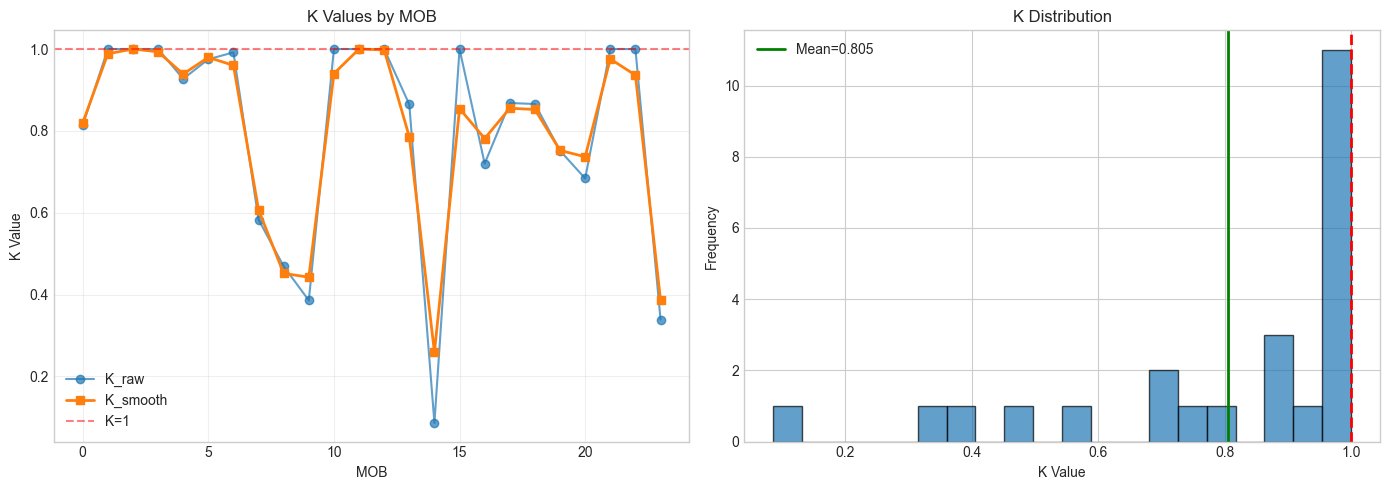

K Statistics: Mean=0.8052, Std=0.2524


In [6]:
# K Values by MOB
plt.style.use('seaborn-v0_8-whitegrid')
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

mobs = sorted(k_raw_by_mob.keys())
k_raw_values = [k_raw_by_mob.get(m, np.nan) for m in mobs]
k_smooth_values = [k_smooth_by_mob.get(m, np.nan) for m in mobs]

axes[0].plot(mobs, k_raw_values, 'o-', label='K_raw', alpha=0.7)
axes[0].plot(mobs, k_smooth_values, 's-', label='K_smooth', linewidth=2)
axes[0].axhline(y=1.0, color='red', linestyle='--', alpha=0.5, label='K=1')
axes[0].set_xlabel('MOB')
axes[0].set_ylabel('K Value')
axes[0].set_title('K Values by MOB')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

k_clean = [v for v in k_raw_values if not np.isnan(v)]
axes[1].hist(k_clean, bins=20, alpha=0.7, edgecolor='black')
axes[1].axvline(x=1.0, color='red', linestyle='--', linewidth=2)
axes[1].axvline(x=np.mean(k_clean), color='green', linestyle='-', linewidth=2, label=f'Mean={np.mean(k_clean):.3f}')
axes[1].set_xlabel('K Value')
axes[1].set_ylabel('Frequency')
axes[1].set_title('K Distribution')
axes[1].legend()

plt.tight_layout()
plt.savefig('outputs/k_values_analysis.png', dpi=150)
plt.show()

print(f'K Statistics: Mean={np.mean(k_clean):.4f}, Std={np.std(k_clean):.4f}')

### 7.2 Build Forecast WITHOUT K for Comparison

⚠️ **QUAN TRỌNG**: Để so sánh công bằng, chỉ lấy PHẦN FORECAST (không bao gồm actual)

- Forecast With K: Sử dụng k_final_by_mob
- Forecast No K: Sử dụng k=1.0 (Markov thuần túy)

In [7]:
# Build PURE forecast WITHOUT K factor (k=1.0 = Markov thuần túy)
k_no_k = {m: 1.0 for m in range(1, MAX_MOB + 1)}

# Forecast without K (Markov thuần túy)
forecast_no_k = forecast_all_vintages_partial_step(
    actual_results=actual_results,
    matrices_by_mob=matrices_by_mob,
    parent_fallback=parent_fallback,
    max_mob=MAX_MOB,
    k_by_mob=k_no_k,
    states=BUCKETS_CANON
)

# Convert to DataFrame
df_forecast_no_k_raw = lifecycle_to_long_df_amount(forecast_no_k)
df_forecast_no_k_raw = tag_forecast_rows_amount(df_forecast_no_k_raw, df_raw)
df_forecast_no_k_raw = add_del_metrics(df_forecast_no_k_raw, df_raw)

# ⚠️ QUAN TRỌNG: Chỉ lấy PHẦN FORECAST (IS_FORECAST == 1)
# Loại bỏ start_mob (điểm bắt đầu forecast = actual cuối cùng)
df_forecast_no_k = df_forecast_no_k_raw[df_forecast_no_k_raw['IS_FORECAST'] == 1].copy()

# Lấy PHẦN FORECAST từ df_lifecycle_final (With K)
df_forecast_with_k = df_lifecycle_final[df_lifecycle_final['IS_FORECAST'] == 1].copy()

# Lấy PHẦN ACTUAL để reference
df_actual_only = df_lifecycle_final[df_lifecycle_final['IS_FORECAST'] == 0].copy()

print(f'Actual data points: {len(df_actual_only):,}')
print(f'Forecast (No K) data points: {len(df_forecast_no_k):,}')
print(f'Forecast (With K) data points: {len(df_forecast_with_k):,}')
print(f'\n⚠️ So sánh sẽ dựa trên PURE FORECAST (IS_FORECAST=1 only)')

# DEBUG: Kiểm tra MOB range
print(f'\n--- DEBUG ---')
print(f'df_forecast_no_k MOB range: {df_forecast_no_k["MOB"].min()} - {df_forecast_no_k["MOB"].max()}')
print(f'df_forecast_with_k MOB range: {df_forecast_with_k["MOB"].min()} - {df_forecast_with_k["MOB"].max()}')
print(f'df_actual_only MOB range: {df_actual_only["MOB"].min()} - {df_actual_only["MOB"].max()}')

# Kiểm tra số cohort
n_cohorts_no_k = df_forecast_no_k.groupby(['PRODUCT_TYPE', 'RISK_SCORE', 'VINTAGE_DATE']).ngroups
n_cohorts_with_k = df_forecast_with_k.groupby(['PRODUCT_TYPE', 'RISK_SCORE', 'VINTAGE_DATE']).ngroups
print(f'\nNumber of cohorts in forecast (No K): {n_cohorts_no_k}')
print(f'Number of cohorts in forecast (With K): {n_cohorts_with_k}')

# Kiểm tra DISB_TOTAL có giống nhau không
print(f'\nDISB_TOTAL check:')
print(f'  No K mean: {df_forecast_no_k["DISB_TOTAL"].mean():,.0f}')
print(f'  With K mean: {df_forecast_with_k["DISB_TOTAL"].mean():,.0f}')

# Kiểm tra DEL30_AMT có khác nhau không
print(f'\nDEL30_AMT check at MOB 10:')
print(f'  No K mean: {df_forecast_no_k[df_forecast_no_k["MOB"]==10]["DEL30_AMT"].mean():,.0f}')
print(f'  With K mean: {df_forecast_with_k[df_forecast_with_k["MOB"]==10]["DEL30_AMT"].mean():,.0f}')

# Kiểm tra sample DEL30_PCT
print(f'\nSample DEL30_PCT at MOB 10:')
print(f'  No K: {df_forecast_no_k[df_forecast_no_k["MOB"]==10]["DEL30_PCT"].mean()*100:.2f}%')
print(f'  With K: {df_forecast_with_k[df_forecast_with_k["MOB"]==10]["DEL30_PCT"].mean()*100:.2f}%')

# So sánh cùng một cohort cụ thể
sample_cohort = df_forecast_with_k.groupby(['PRODUCT_TYPE', 'RISK_SCORE', 'VINTAGE_DATE']).first().index[0]
print(f'\n--- So sánh cohort: {sample_cohort} ---')
df_sample_no_k = df_forecast_no_k[
    (df_forecast_no_k['PRODUCT_TYPE'] == sample_cohort[0]) &
    (df_forecast_no_k['RISK_SCORE'] == sample_cohort[1]) &
    (df_forecast_no_k['VINTAGE_DATE'] == sample_cohort[2])
].sort_values('MOB')
df_sample_with_k = df_forecast_with_k[
    (df_forecast_with_k['PRODUCT_TYPE'] == sample_cohort[0]) &
    (df_forecast_with_k['RISK_SCORE'] == sample_cohort[1]) &
    (df_forecast_with_k['VINTAGE_DATE'] == sample_cohort[2])
].sort_values('MOB')

print(f'No K MOBs: {df_sample_no_k["MOB"].tolist()}')
print(f'With K MOBs: {df_sample_with_k["MOB"].tolist()}')
print(f'\nNo K DEL30_PCT: {(df_sample_no_k["DEL30_PCT"]*100).round(2).tolist()}')
print(f'With K DEL30_PCT: {(df_sample_with_k["DEL30_PCT"]*100).round(2).tolist()}')

Actual data points: 5,171
Forecast (No K) data points: 2,703
Forecast (With K) data points: 2,703

⚠️ So sánh sẽ dựa trên PURE FORECAST (IS_FORECAST=1 only)

--- DEBUG ---
df_forecast_no_k MOB range: 1 - 24
df_forecast_with_k MOB range: 1 - 24
df_actual_only MOB range: -1 - 24

Number of cohorts in forecast (No K): 211
Number of cohorts in forecast (With K): 211

DISB_TOTAL check:
  No K mean: 26
  With K mean: 26

DEL30_AMT check at MOB 10:
  No K mean: 5
  With K mean: 4

Sample DEL30_PCT at MOB 10:
  No K: 15.24%
  With K: 13.04%

--- So sánh cohort: ('T', 'A', Timestamp('2024-01-01 00:00:00')) ---
No K MOBs: [24]
With K MOBs: [24]

No K DEL30_PCT: [8.64]
With K DEL30_PCT: [8.56]


### 7.3 DEL30+ Rate Curves Comparison: Actual vs Forecast (No K) vs Forecast (With K)

So sánh DEL30+ Rate (%) = DEL30_AMT / DISB_TOTAL (giải ngân ban đầu)

- **Actual**: Dữ liệu thực tế (IS_FORECAST=0)
- **Forecast (No K)**: Dự báo không có K factor (K=1)
- **Forecast (With K)**: Dự báo có K factor đã calibrate

In [8]:
# Aggregate DEL30_PCT by MOB - CHỈ PHẦN FORECAST
# DEL30_PCT = DEL30_AMT / DISB_TOTAL (calculated correctly in add_del_metrics)

# Only Actual (IS_FORECAST=0) - để reference
agg_actual = df_actual_only.groupby('MOB')['DEL30_PCT'].mean() * 100

# PURE Forecast No K (Markov thuần túy)
agg_fc_no_k = df_forecast_no_k.groupby('MOB')['DEL30_PCT'].mean() * 100

# PURE Forecast With K (có calibration)
agg_fc_with_k = df_forecast_with_k.groupby('MOB')['DEL30_PCT'].mean() * 100

print(f'Actual MOB range: {agg_actual.index.min()} - {agg_actual.index.max()}')
print(f'Forecast (No K) MOB range: {agg_fc_no_k.index.min()} - {agg_fc_no_k.index.max()}')
print(f'Forecast (With K) MOB range: {agg_fc_with_k.index.min()} - {agg_fc_with_k.index.max()}')
print(f'\nSample DEL30+ Rate (Actual): {agg_actual.mean():.2f}%')
print(f'Sample DEL30+ Rate (Forecast No K): {agg_fc_no_k.mean():.2f}%')
print(f'Sample DEL30+ Rate (Forecast With K): {agg_fc_with_k.mean():.2f}%')
print(f'\n⚠️ Lưu ý: Đây là PURE FORECAST comparison (không bao gồm actual trong aggregate)')

Actual MOB range: -1 - 24
Forecast (No K) MOB range: 1 - 24
Forecast (With K) MOB range: 1 - 24

Sample DEL30+ Rate (Actual): 14.11%
Sample DEL30+ Rate (Forecast No K): 16.24%
Sample DEL30+ Rate (Forecast With K): 14.70%

⚠️ Lưu ý: Đây là PURE FORECAST comparison (không bao gồm actual trong aggregate)


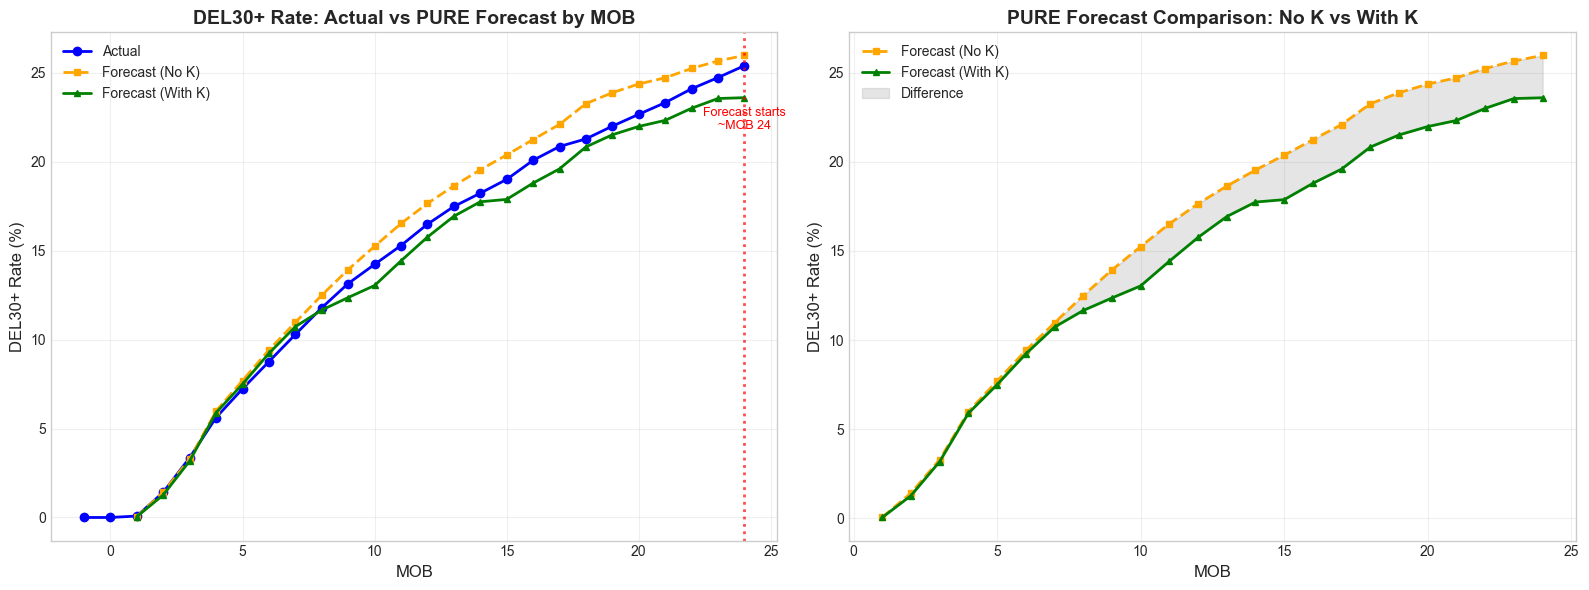


Actual DEL30+ Rate range: 0.00% - 25.39%
Forecast (No K) DEL30+ Rate range: 0.06% - 25.97%
Forecast (With K) DEL30+ Rate range: 0.05% - 23.59%

Mean difference (No K - With K): 1.54 pp


In [9]:
# DEL30+ Rate Curves by MOB - PURE FORECAST COMPARISON
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Chart 1: Actual vs Pure Forecasts
axes[0].plot(agg_actual.index, agg_actual.values, 'o-', label='Actual', linewidth=2, markersize=6, color='blue')
axes[0].plot(agg_fc_no_k.index, agg_fc_no_k.values, 's--', label='Forecast (No K)', linewidth=2, markersize=5, color='orange')
axes[0].plot(agg_fc_with_k.index, agg_fc_with_k.values, '^-', label='Forecast (With K)', linewidth=2, markersize=5, color='green')

# Mark where forecast starts
max_actual_mob = agg_actual.index.max()
axes[0].axvline(x=max_actual_mob, color='red', linestyle=':', linewidth=2, alpha=0.7)
axes[0].annotate(f'Forecast starts\n~MOB {max_actual_mob}', xy=(max_actual_mob, axes[0].get_ylim()[1]*0.8),
                 fontsize=9, color='red', ha='center')

axes[0].set_xlabel('MOB', fontsize=12)
axes[0].set_ylabel('DEL30+ Rate (%)', fontsize=12)
axes[0].set_title('DEL30+ Rate: Actual vs PURE Forecast by MOB', fontsize=14, fontweight='bold')
axes[0].legend(fontsize=10)
axes[0].grid(True, alpha=0.3)

# Chart 2: Forecast Comparison Only (No K vs With K)
axes[1].plot(agg_fc_no_k.index, agg_fc_no_k.values, 's--', label='Forecast (No K)', linewidth=2, markersize=5, color='orange')
axes[1].plot(agg_fc_with_k.index, agg_fc_with_k.values, '^-', label='Forecast (With K)', linewidth=2, markersize=5, color='green')

# Add difference shading
common_mobs = sorted(set(agg_fc_no_k.index) & set(agg_fc_with_k.index))
if len(common_mobs) > 0:
    no_k_vals = [agg_fc_no_k.get(m, np.nan) for m in common_mobs]
    with_k_vals = [agg_fc_with_k.get(m, np.nan) for m in common_mobs]
    axes[1].fill_between(common_mobs, no_k_vals, with_k_vals, alpha=0.2, color='gray', label='Difference')

axes[1].set_xlabel('MOB', fontsize=12)
axes[1].set_ylabel('DEL30+ Rate (%)', fontsize=12)
axes[1].set_title('PURE Forecast Comparison: No K vs With K', fontsize=14, fontweight='bold')
axes[1].legend(fontsize=10)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('outputs/del30_rate_curves_comparison.png', dpi=150)
plt.show()

print(f'\nActual DEL30+ Rate range: {agg_actual.min():.2f}% - {agg_actual.max():.2f}%')
print(f'Forecast (No K) DEL30+ Rate range: {agg_fc_no_k.min():.2f}% - {agg_fc_no_k.max():.2f}%')
print(f'Forecast (With K) DEL30+ Rate range: {agg_fc_with_k.min():.2f}% - {agg_fc_with_k.max():.2f}%')
print(f'\nMean difference (No K - With K): {(agg_fc_no_k.mean() - agg_fc_with_k.mean()):.2f} pp')

### 7.4 MAE & MAPE Analysis: Forecast Accuracy

So sánh forecast với actual tại các MOB có overlap (các cohort khác nhau có max actual MOB khác nhau)

In [10]:
# Find MOBs where we have BOTH actual and forecast data (from different cohorts)
# At MOB X: some cohorts have actual, some have forecast

common_mobs = set(agg_actual.index) & set(agg_fc_with_k.index)
print(f'MOBs with both actual and forecast data: {sorted(common_mobs)}')

if len(common_mobs) > 0:
    # Calculate MAE/MAPE at portfolio level
    def calc_mae_mape(actual, forecast):
        actual = np.array(actual)
        forecast = np.array(forecast)
        mask = ~(np.isnan(actual) | np.isnan(forecast))
        actual, forecast = actual[mask], forecast[mask]
        if len(actual) == 0:
            return np.nan, np.nan
        mae = np.mean(np.abs(actual - forecast))
        nonzero = actual > 0.01
        mape = np.mean(np.abs((actual[nonzero] - forecast[nonzero]) / actual[nonzero])) * 100 if nonzero.sum() > 0 else np.nan
        return mae, mape
    
    actual_vals = [agg_actual.get(m, np.nan) for m in sorted(common_mobs)]
    with_k_vals = [agg_fc_with_k.get(m, np.nan) for m in sorted(common_mobs)]
    no_k_vals = [agg_fc_no_k.get(m, np.nan) for m in sorted(common_mobs)]
    
    mae_with_k, mape_with_k = calc_mae_mape(actual_vals, with_k_vals)
    mae_no_k, mape_no_k = calc_mae_mape(actual_vals, no_k_vals)
    
    print(f'\nPortfolio-level comparison at common MOBs:')
    print(f'  MAE (No K): {mae_no_k:.3f} pp')
    print(f'  MAE (With K): {mae_with_k:.3f} pp')
    print(f'  MAE Improvement: {(mae_no_k - mae_with_k) / mae_no_k * 100:.1f}%' if mae_no_k > 0 else 'N/A')
    print(f'\n  MAPE (No K): {mape_no_k:.2f}%')
    print(f'  MAPE (With K): {mape_with_k:.2f}%')
    print(f'  MAPE Improvement: {(mape_no_k - mape_with_k) / mape_no_k * 100:.1f}%' if mape_no_k > 0 else 'N/A')
else:
    print('\n⚠️ No common MOBs between actual and forecast!')
    print('This means all cohorts have the same max actual MOB.')

MOBs with both actual and forecast data: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24]

Portfolio-level comparison at common MOBs:
  MAE (No K): 0.960 pp
  MAE (With K): 0.703 pp
  MAE Improvement: 26.8%

  MAPE (No K): 7.13%
  MAPE (With K): 6.51%
  MAPE Improvement: 8.7%



Detailed comparison by MOB:
 MOB  Actual (%)  Forecast No K (%)  Forecast With K (%)  Error No K (pp)  Error With K (pp)
   1    0.081403           0.055034             0.045098        -0.026369          -0.036305
   2    1.419064           1.415225             1.268845        -0.003839          -0.150219
   3    3.364209           3.292239             3.180588        -0.071969          -0.183621
   4    5.619139           5.983857             5.890545         0.364718           0.271406
   5    7.233248           7.697434             7.495566         0.464186           0.262318
   6    8.761181           9.415509             9.223247         0.654328           0.462066
   7   10.288390          10.964157            10.727251         0.675768           0.438861
   8   11.787989          12.495544            11.658559         0.707555          -0.129430
   9   13.149294          13.934925            12.361770         0.785631          -0.787524
  10   14.225388          15.242525      

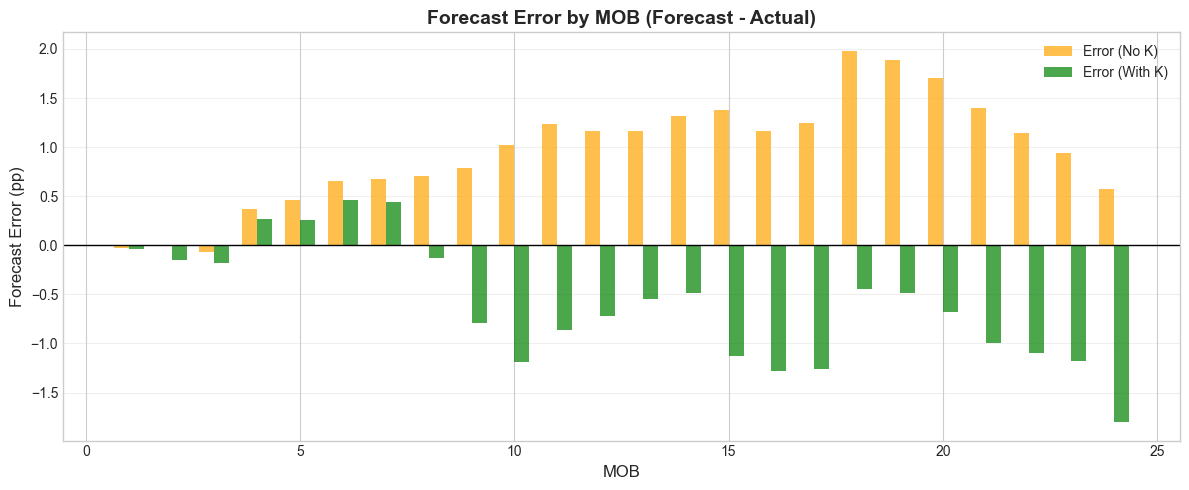

In [11]:
# Detailed comparison by MOB
if len(common_mobs) > 0:
    metrics_by_mob = []
    for mob in sorted(common_mobs):
        actual_val = agg_actual.get(mob, np.nan)
        no_k_val = agg_fc_no_k.get(mob, np.nan)
        with_k_val = agg_fc_with_k.get(mob, np.nan)
        
        if not np.isnan(actual_val) and not np.isnan(no_k_val) and not np.isnan(with_k_val):
            error_no_k = no_k_val - actual_val
            error_with_k = with_k_val - actual_val
            
            metrics_by_mob.append({
                'MOB': mob,
                'Actual (%)': actual_val,
                'Forecast No K (%)': no_k_val,
                'Forecast With K (%)': with_k_val,
                'Error No K (pp)': error_no_k,
                'Error With K (pp)': error_with_k,
            })
    
    df_metrics_mob = pd.DataFrame(metrics_by_mob)
    print('\nDetailed comparison by MOB:')
    print(df_metrics_mob.to_string(index=False))
    
    # Chart: Error by MOB
    fig, ax = plt.subplots(figsize=(12, 5))
    x = df_metrics_mob['MOB']
    width = 0.35
    ax.bar(x - width/2, df_metrics_mob['Error No K (pp)'], width, label='Error (No K)', color='orange', alpha=0.7)
    ax.bar(x + width/2, df_metrics_mob['Error With K (pp)'], width, label='Error (With K)', color='green', alpha=0.7)
    ax.axhline(y=0, color='black', linestyle='-', linewidth=1)
    ax.set_xlabel('MOB', fontsize=12)
    ax.set_ylabel('Forecast Error (pp)', fontsize=12)
    ax.set_title('Forecast Error by MOB (Forecast - Actual)', fontsize=14, fontweight='bold')
    ax.legend(fontsize=10)
    ax.grid(True, alpha=0.3, axis='y')
    plt.tight_layout()
    plt.savefig('outputs/forecast_error_by_mob.png', dpi=150)
    plt.show()

### 7.5 MAE & MAPE by Cohort Level

Tính MAE/MAPE chi tiết theo từng cohort (Product × Score × Vintage)

In [12]:
# Merge actual and forecast at cohort level for detailed comparison
# Only compare at MOBs where we have BOTH actual and forecast for the SAME cohort
# ⚠️ IMPORTANT: Using PURE FORECASTS (created in Section 7.2)

# Get actual data (for reference)
df_actual_cohort = df_actual_only[['PRODUCT_TYPE', 'RISK_SCORE', 'VINTAGE_DATE', 'MOB', 'DEL30_PCT']].copy()
df_actual_cohort = df_actual_cohort.rename(columns={'DEL30_PCT': 'DEL30_PCT_ACTUAL'})

# Get PURE forecast data (With K) - already created in Section 7.2
df_fc_with_k_cohort = df_forecast_with_k[['PRODUCT_TYPE', 'RISK_SCORE', 'VINTAGE_DATE', 'MOB', 'DEL30_PCT']].copy()
df_fc_with_k_cohort = df_fc_with_k_cohort.rename(columns={'DEL30_PCT': 'DEL30_PCT_WITH_K'})

# Get PURE forecast data (No K) - already created in Section 7.2
df_fc_no_k_cohort = df_forecast_no_k[['PRODUCT_TYPE', 'RISK_SCORE', 'VINTAGE_DATE', 'MOB', 'DEL30_PCT']].copy()
df_fc_no_k_cohort = df_fc_no_k_cohort.rename(columns={'DEL30_PCT': 'DEL30_PCT_NO_K'})

# Note: For same cohort, actual and forecast are at DIFFERENT MOBs
# So we compare across cohorts at same MOB
print(f'Actual data points: {len(df_actual_cohort):,}')
print(f'Forecast (With K) data points: {len(df_fc_with_k_cohort):,}')
print(f'Forecast (No K) data points: {len(df_fc_no_k_cohort):,}')
print(f'\n⚠️ Using PURE FORECAST data (không bao gồm actual trong aggregate)')

Actual data points: 5,171
Forecast (With K) data points: 2,703
Forecast (No K) data points: 2,703

⚠️ Using PURE FORECAST data (không bao gồm actual trong aggregate)


In [13]:
# MAE & MAPE by Product
def calc_mae_mape_series(actual, forecast):
    actual = np.array(actual)
    forecast = np.array(forecast)
    mask = ~(np.isnan(actual) | np.isnan(forecast))
    actual, forecast = actual[mask], forecast[mask]
    if len(actual) == 0:
        return np.nan, np.nan
    mae = np.mean(np.abs(actual - forecast))
    nonzero = actual > 0.0001
    mape = np.mean(np.abs((actual[nonzero] - forecast[nonzero]) / actual[nonzero])) * 100 if nonzero.sum() > 0 else np.nan
    return mae, mape

# Aggregate by Product for comparison - using PURE forecasts
agg_actual_prod = df_actual_only.groupby(['PRODUCT_TYPE', 'MOB'])['DEL30_PCT'].mean()
agg_fc_with_k_prod = df_forecast_with_k.groupby(['PRODUCT_TYPE', 'MOB'])['DEL30_PCT'].mean()
agg_fc_no_k_prod = df_forecast_no_k.groupby(['PRODUCT_TYPE', 'MOB'])['DEL30_PCT'].mean()

# Calculate metrics by product
products = df_lifecycle_final['PRODUCT_TYPE'].unique()
metrics_by_product = []

for product in products:
    # Get MOBs with both actual and forecast for this product
    actual_mobs = set(agg_actual_prod.loc[product].index) if product in agg_actual_prod.index.get_level_values(0) else set()
    fc_mobs = set(agg_fc_with_k_prod.loc[product].index) if product in agg_fc_with_k_prod.index.get_level_values(0) else set()
    common = actual_mobs & fc_mobs
    
    if len(common) < 3:
        continue
    
    actual_vals = [agg_actual_prod.loc[(product, m)] * 100 for m in sorted(common)]
    with_k_vals = [agg_fc_with_k_prod.loc[(product, m)] * 100 for m in sorted(common)]
    no_k_vals = [agg_fc_no_k_prod.loc[(product, m)] * 100 for m in sorted(common)]
    
    mae_with_k, mape_with_k = calc_mae_mape_series(actual_vals, with_k_vals)
    mae_no_k, mape_no_k = calc_mae_mape_series(actual_vals, no_k_vals)
    
    metrics_by_product.append({
        'Product': product,
        'MAE_No_K': mae_no_k,
        'MAE_With_K': mae_with_k,
        'MAE_Improvement': (mae_no_k - mae_with_k) / mae_no_k * 100 if mae_no_k > 0 else 0,
        'MAPE_No_K': mape_no_k,
        'MAPE_With_K': mape_with_k,
        'MAPE_Improvement': (mape_no_k - mape_with_k) / mape_no_k * 100 if mape_no_k > 0 else 0,
        'N_MOBs': len(common)
    })

df_metrics_prod = pd.DataFrame(metrics_by_product)
if len(df_metrics_prod) > 0:
    print('\nMAE & MAPE by Product:')
    print(df_metrics_prod.to_string(index=False))
    df_metrics_prod.to_excel('outputs/mae_mape_by_product.xlsx', index=False)
    print('\nSaved to outputs/mae_mape_by_product.xlsx')
else:
    print('\n⚠️ Not enough overlapping MOBs to calculate metrics by product')


MAE & MAPE by Product:
Product  MAE_No_K  MAE_With_K  MAE_Improvement  MAPE_No_K  MAPE_With_K  MAPE_Improvement  N_MOBs
      T  0.860937    1.436336       -66.834103  10.332697    12.759662        -23.488202      24
      X  1.341402    0.494547        63.132094   8.915817     5.274834         40.837351      24

Saved to outputs/mae_mape_by_product.xlsx


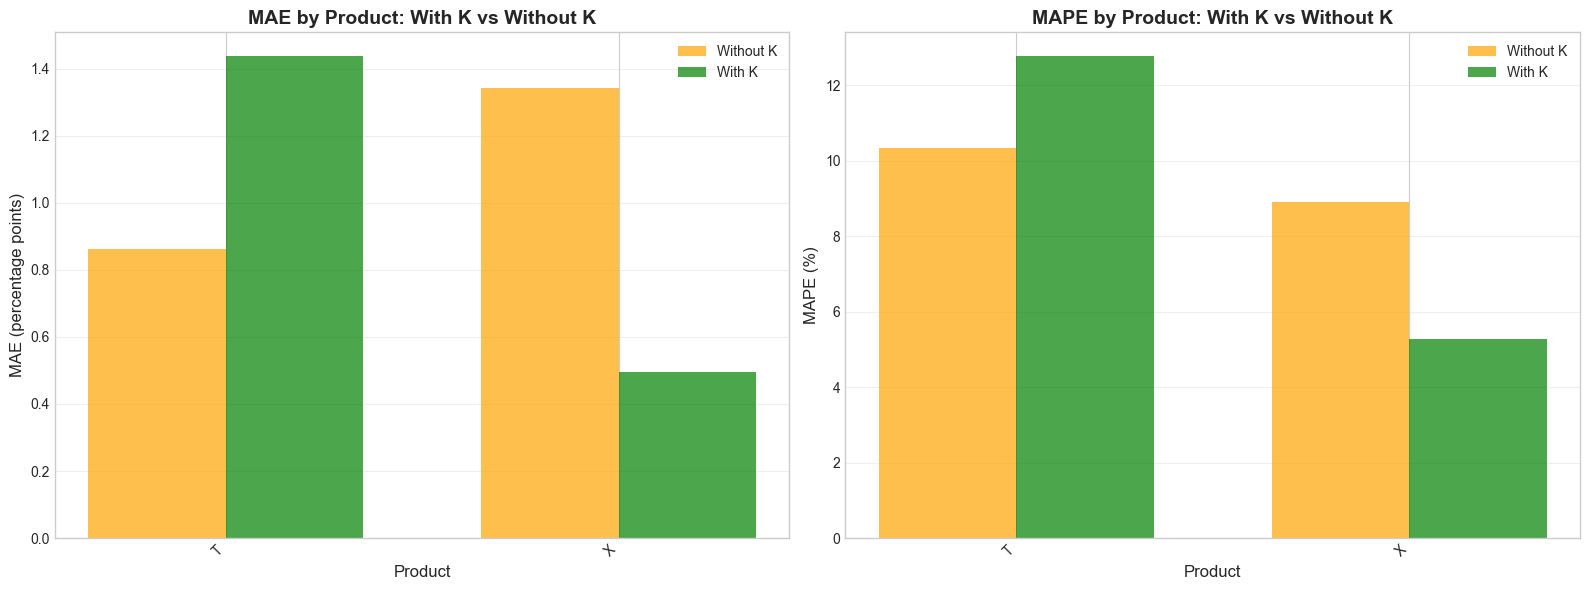

In [14]:
# Chart: MAE & MAPE by Product
if len(df_metrics_prod) > 0:
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    
    # MAE Comparison by Product
    x = np.arange(len(df_metrics_prod))
    width = 0.35
    axes[0].bar(x - width/2, df_metrics_prod['MAE_No_K'], width, label='Without K', color='orange', alpha=0.7)
    axes[0].bar(x + width/2, df_metrics_prod['MAE_With_K'], width, label='With K', color='green', alpha=0.7)
    axes[0].set_xlabel('Product', fontsize=12)
    axes[0].set_ylabel('MAE (percentage points)', fontsize=12)
    axes[0].set_title('MAE by Product: With K vs Without K', fontsize=14, fontweight='bold')
    axes[0].set_xticks(x)
    axes[0].set_xticklabels(df_metrics_prod['Product'], rotation=45, ha='right')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3, axis='y')
    
    # MAPE Comparison by Product
    axes[1].bar(x - width/2, df_metrics_prod['MAPE_No_K'], width, label='Without K', color='orange', alpha=0.7)
    axes[1].bar(x + width/2, df_metrics_prod['MAPE_With_K'], width, label='With K', color='green', alpha=0.7)
    axes[1].set_xlabel('Product', fontsize=12)
    axes[1].set_ylabel('MAPE (%)', fontsize=12)
    axes[1].set_title('MAPE by Product: With K vs Without K', fontsize=14, fontweight='bold')
    axes[1].set_xticks(x)
    axes[1].set_xticklabels(df_metrics_prod['Product'], rotation=45, ha='right')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3, axis='y')
    
    plt.tight_layout()
    plt.savefig('outputs/mae_mape_by_product.png', dpi=150)
    plt.show()

### 7.6 DEL30+ Analysis Charts

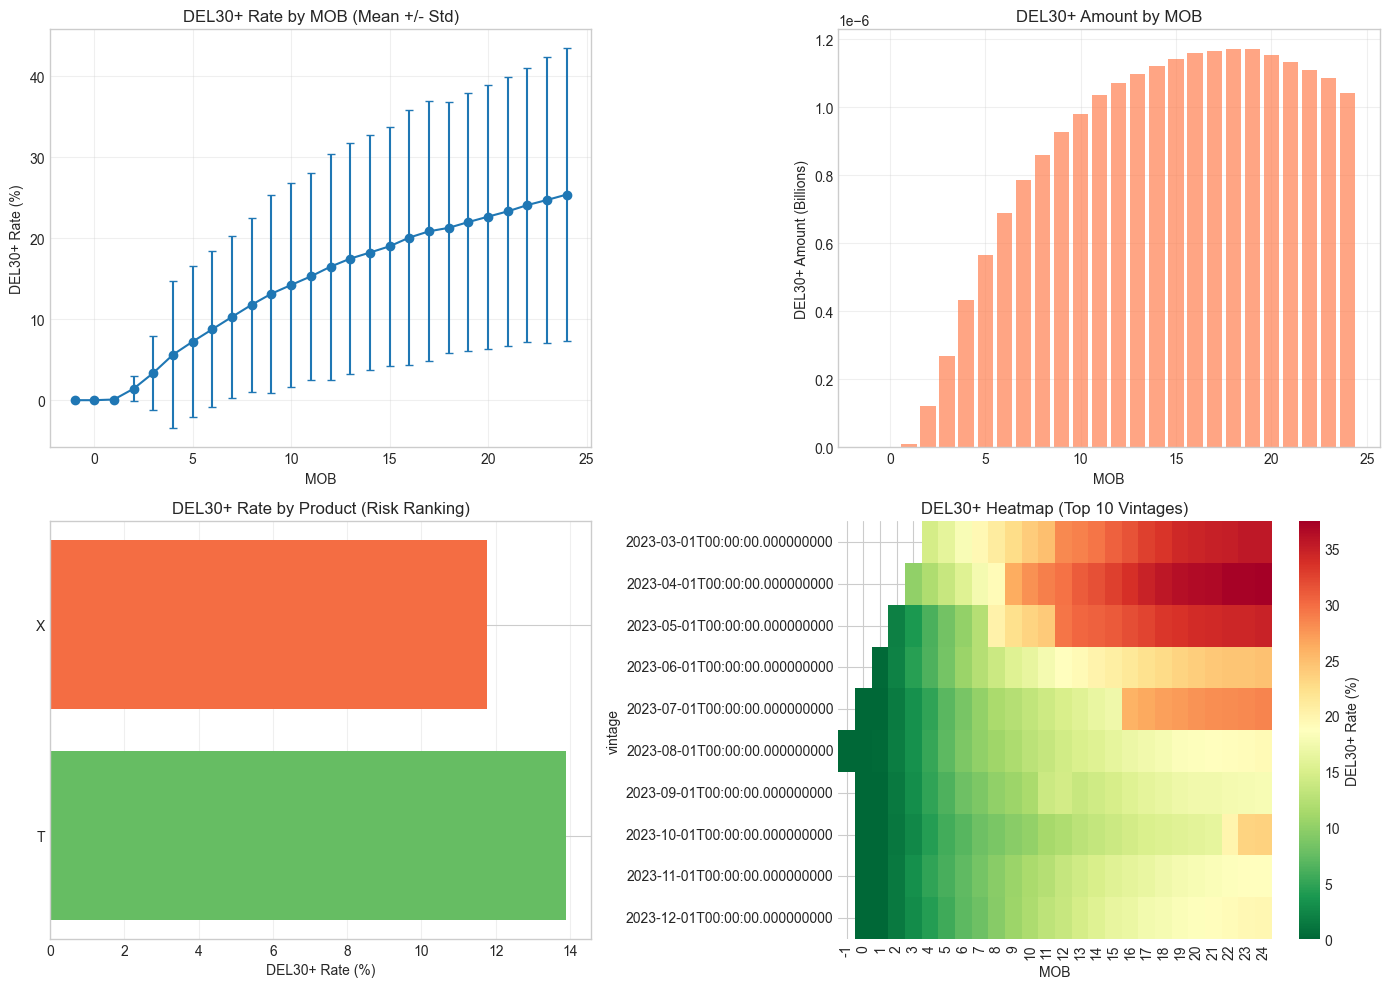

In [15]:
# Prepare backtest data from df_lifecycle_final (actual only)
df_backtest = df_lifecycle_final[df_lifecycle_final['IS_FORECAST'] == 0].copy()
df_backtest = df_backtest.rename(columns={'DEL30_PCT': 'del30_rate', 'PRODUCT_TYPE': 'product', 'VINTAGE_DATE': 'vintage'})

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# DEL30+ Rate by MOB
del30_by_mob = df_backtest.groupby('MOB')['del30_rate'].agg(['mean', 'std'])
axes[0,0].errorbar(del30_by_mob.index, del30_by_mob['mean'] * 100, yerr=del30_by_mob['std'] * 100, fmt='o-', capsize=3)
axes[0,0].set_xlabel('MOB')
axes[0,0].set_ylabel('DEL30+ Rate (%)')
axes[0,0].set_title('DEL30+ Rate by MOB (Mean +/- Std)')
axes[0,0].grid(True, alpha=0.3)

# DEL30+ Amount by MOB
del30_amt = df_backtest.groupby('MOB')['DEL30_AMT'].sum() / 1e9
axes[0,1].bar(del30_amt.index, del30_amt.values, alpha=0.7, color='coral')
axes[0,1].set_xlabel('MOB')
axes[0,1].set_ylabel('DEL30+ Amount (Billions)')
axes[0,1].set_title('DEL30+ Amount by MOB')
axes[0,1].grid(True, alpha=0.3)

# DEL30+ by Product
del30_prod = df_backtest.groupby('product')['del30_rate'].mean().sort_values(ascending=False) * 100
colors = plt.cm.RdYlGn_r(np.linspace(0.2, 0.8, len(del30_prod)))
axes[1,0].barh(del30_prod.index, del30_prod.values, color=colors)
axes[1,0].set_xlabel('DEL30+ Rate (%)')
axes[1,0].set_title('DEL30+ Rate by Product (Risk Ranking)')
axes[1,0].grid(True, alpha=0.3, axis='x')

# Heatmap
top_vintages = df_backtest.groupby('vintage')['DISB_TOTAL'].sum().nlargest(10).index
df_top = df_backtest[df_backtest['vintage'].isin(top_vintages)]
pivot = df_top.pivot_table(values='del30_rate', index='vintage', columns='MOB', aggfunc='mean') * 100
sns.heatmap(pivot, ax=axes[1,1], cmap='RdYlGn_r', cbar_kws={'label': 'DEL30+ Rate (%)'})
axes[1,1].set_title('DEL30+ Heatmap (Top 10 Vintages)')

plt.tight_layout()
plt.savefig('outputs/model_evaluation_charts.png', dpi=150)
plt.show()

### 7.7 Model Performance Summary

In [16]:
print('='*60)
print('MODEL PERFORMANCE SUMMARY')
print('='*60)

k_clean = [v for v in k_raw_by_mob.values() if not np.isnan(v)]
k_smooth_clean = [v for v in k_smooth_by_mob.values() if not np.isnan(v)]

print('\nK-Factor Analysis:')
print(f'   K_raw Mean: {np.mean(k_clean):.4f}')
print(f'   K_raw Std: {np.std(k_clean):.4f}')
print(f'   K_smooth Mean: {np.mean(k_smooth_clean):.4f}')
print(f'   Alpha: {alpha:.4f}')

k_mean = np.mean(k_clean)
if k_mean > 1.1:
    interp = 'Model UNDER-estimates risk -> K > 1 scales up'
elif k_mean < 0.9:
    interp = 'Model OVER-estimates risk -> K < 1 scales down'
else:
    interp = 'Model is well-calibrated (K ~ 1)'
print(f'\nInterpretation: {interp}')

print('\nData Coverage:')
print(f'   Total cohorts: {len(actual_results):,}')
print(f'   Products: {len(matrices_by_mob)}')
print(f'   MOB range: {mob_min} - {mob_max}')

print('\nForecast Summary:')
print(f'   Total rows: {len(df_lifecycle_final):,}')
print(f'   Actual: {(df_lifecycle_final["IS_FORECAST"]==0).sum():,}')
print(f'   Forecast: {(df_lifecycle_final["IS_FORECAST"]==1).sum():,}')

print('\nDEL30+ Rate Summary (Actual):')
print(f'   Mean: {agg_actual.mean():.2f}%')
print(f'   Min: {agg_actual.min():.2f}%')
print(f'   Max: {agg_actual.max():.2f}%')
print('='*60)

MODEL PERFORMANCE SUMMARY

K-Factor Analysis:
   K_raw Mean: 0.8052
   K_raw Std: 0.2524
   K_smooth Mean: 0.8039
   Alpha: 1.0000

Interpretation: Model OVER-estimates risk -> K < 1 scales down

Data Coverage:
   Total cohorts: 323
   Products: 2
   MOB range: 0 - 23

Forecast Summary:
   Total rows: 7,874
   Actual: 5,171
   Forecast: 2,703

DEL30+ Rate Summary (Actual):
   Mean: 14.11%
   Min: 0.00%
   Max: 25.39%


### 7.8 Vintage Curves

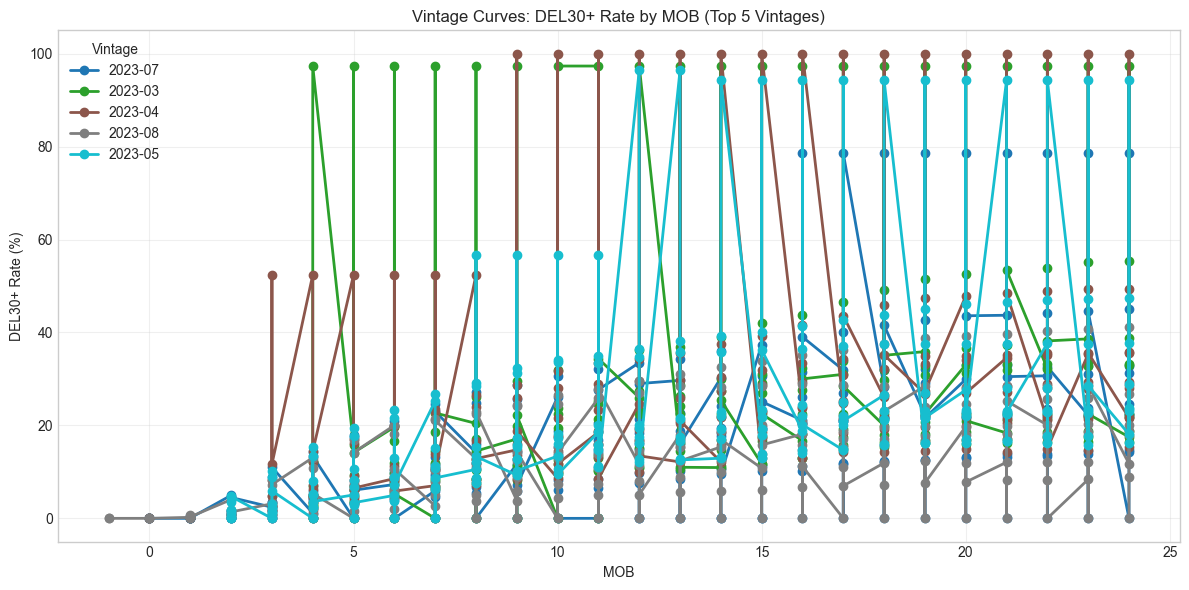

In [17]:
vintages_to_plot = df_backtest.groupby('vintage')['DISB_TOTAL'].sum().nlargest(5).index.tolist()

fig, ax = plt.subplots(figsize=(12, 6))
colors = plt.cm.tab10(np.linspace(0, 1, len(vintages_to_plot)))

for i, vintage in enumerate(vintages_to_plot):
    df_v = df_backtest[df_backtest['vintage'] == vintage].sort_values('MOB')
    label = vintage.strftime('%Y-%m') if hasattr(vintage, 'strftime') else str(vintage)
    ax.plot(df_v['MOB'], df_v['del30_rate'] * 100, 'o-', label=label, color=colors[i], linewidth=2)

ax.set_xlabel('MOB')
ax.set_ylabel('DEL30+ Rate (%)')
ax.set_title('Vintage Curves: DEL30+ Rate by MOB (Top 5 Vintages)')
ax.legend(title='Vintage')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('outputs/vintage_curves.png', dpi=150)
plt.show()

### 7.9 Transition Matrix Visualization

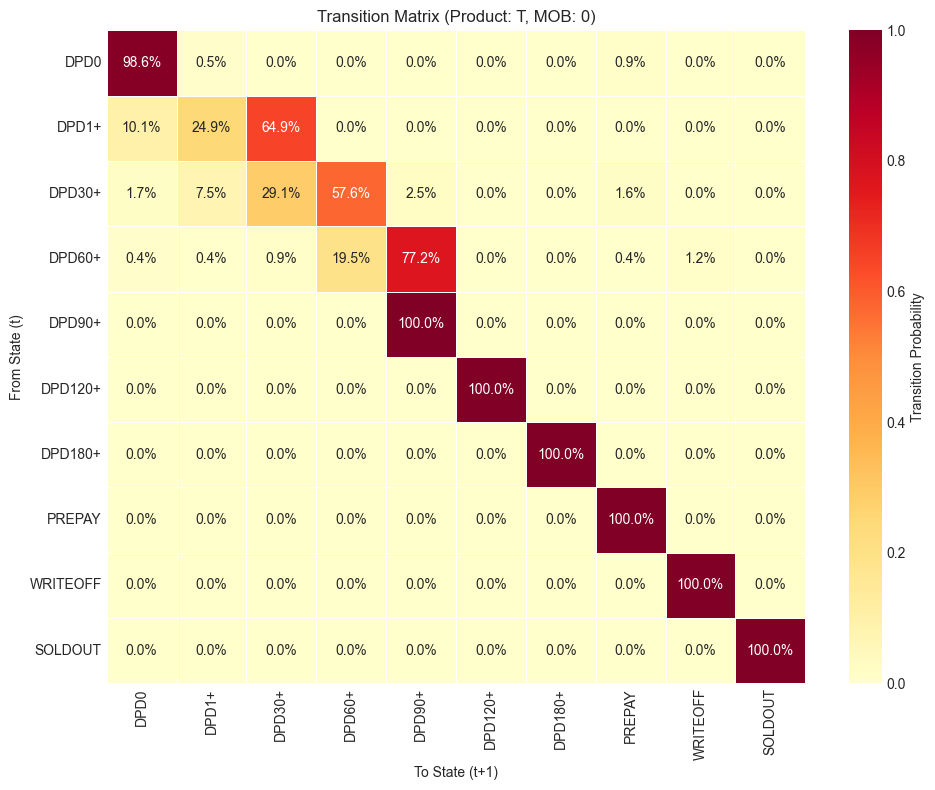

In [18]:
sample_product = list(matrices_by_mob.keys())[0]
sample_mob = list(matrices_by_mob[sample_product].keys())[0]
sample_score = list(matrices_by_mob[sample_product][sample_mob].keys())[0]
sample_tm = matrices_by_mob[sample_product][sample_mob][sample_score]['P']

main_buckets = [b for b in BUCKETS_CANON if b in sample_tm.index and b in sample_tm.columns]
tm_filtered = sample_tm.loc[main_buckets, main_buckets]

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(tm_filtered, annot=True, fmt='.1%', cmap='YlOrRd', ax=ax,
            cbar_kws={'label': 'Transition Probability'}, linewidths=0.5)
ax.set_title(f'Transition Matrix (Product: {sample_product}, MOB: {sample_mob})')
ax.set_xlabel('To State (t+1)')
ax.set_ylabel('From State (t)')

plt.tight_layout()
plt.savefig('outputs/transition_matrix_heatmap.png', dpi=150)
plt.show()

### 7.10 Advanced Model Evaluation

📊 RUNNING FULL MODEL EVALUATION

1️⃣ Preparing backtest data...
   ✅ Backtest data: 4,313 observations

2️⃣ Analyzing K stability...
   ✅ K stability: High variability (CV > 30%) - consider more smoothing

3️⃣ Analyzing concentration risk...
   ✅ HHI: 0.6279 (Concentrated)

4️⃣ Comparing with/without K factor...
   ✅ Comparison data: 4,262 observations

5️⃣ Creating executive summary...
✅ Executive summary saved to: outputs\executive_summary_20260120_100304.txt

6️⃣ Creating dashboard...


C:\Users\User\Projection_PB\Projection_pb\model_evaluation.py:487: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) Arial.
  plt.savefig(output_file, dpi=150, bbox_inches='tight', facecolor='white')
C:\Users\User\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\IPython\core\pylabtools.py:151: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


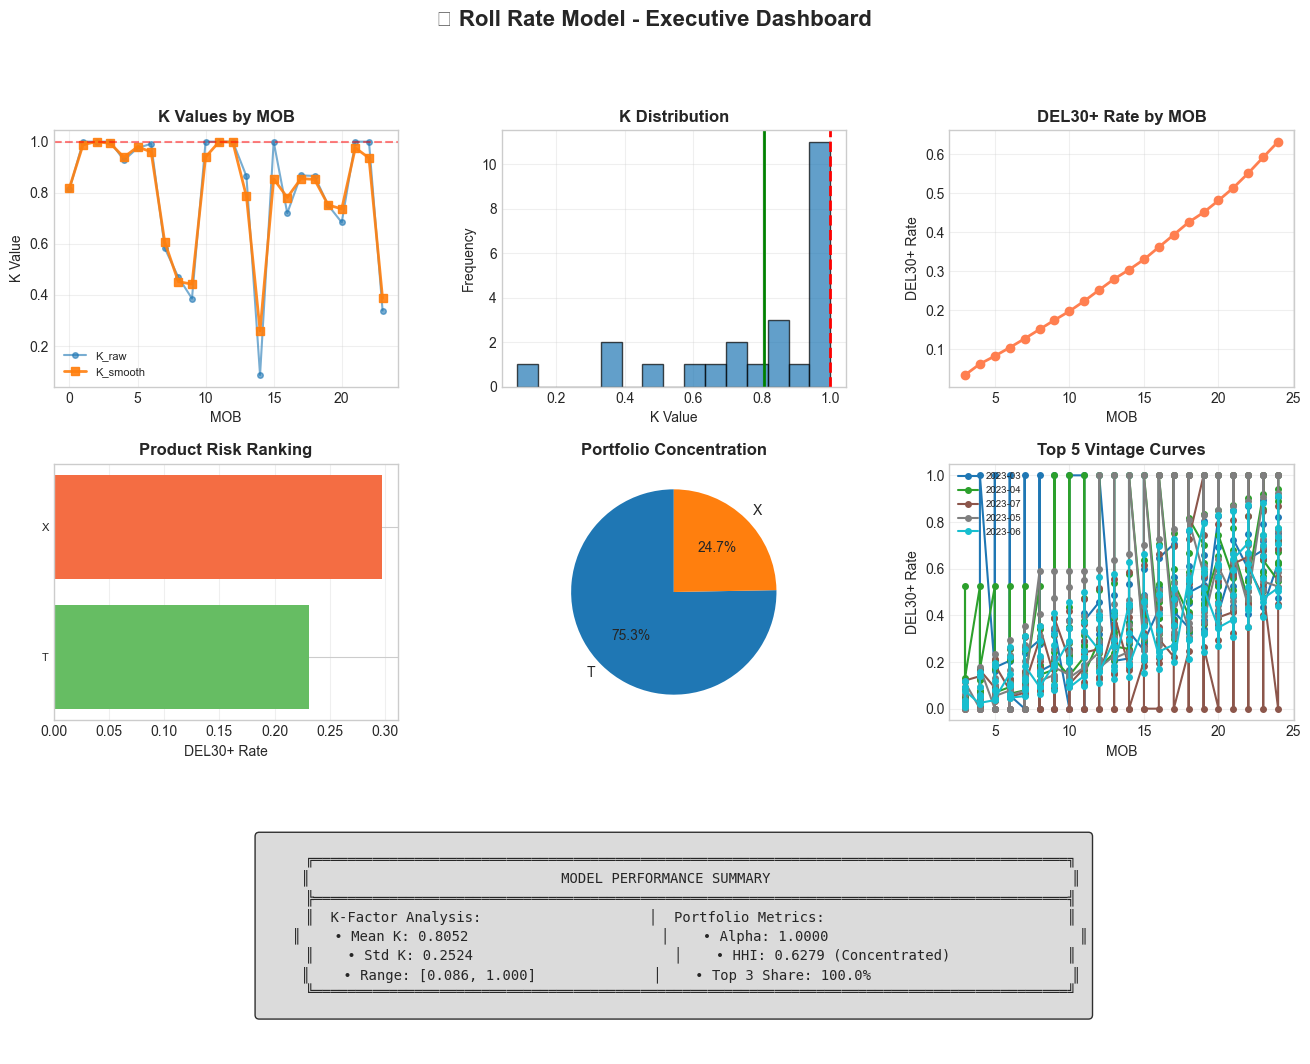

✅ Dashboard saved to: outputs\model_dashboard_20260120_100304.png

✅ EVALUATION COMPLETE!


In [19]:
import importlib
import model_evaluation
importlib.reload(model_evaluation)
from model_evaluation import run_full_evaluation

eval_results = run_full_evaluation(
    actual_results=actual_results,
    matrices_by_mob=matrices_by_mob,
    parent_fallback=parent_fallback,
    k_raw_by_mob=k_raw_by_mob,
    k_smooth_by_mob=k_smooth_by_mob,
    k_final_by_mob=k_final_by_mob,
    df_lifecycle_final=df_lifecycle_final,
    alpha=alpha,
    states=BUCKETS_CANON,
    s30_states=BUCKETS_30P,
    output_dir='outputs')

### 7.11 Evaluation Results Summary

In [20]:
print('='*60)
print('EVALUATION RESULTS SUMMARY')
print('='*60)

k_stab = eval_results['k_stability']
print('\nK-Factor Stability:')
print(f'   Mean K_raw: {k_stab["k_raw_mean"]:.4f}')
print(f'   CV: {k_stab["k_raw_cv"]:.2%}')
print(f'   Assessment: {k_stab["interpretation"]}')

conc = eval_results['concentration']
print('\nConcentration Risk:')
print(f'   HHI Index: {conc.get("hhi", 0):.4f}')
print(f'   Assessment: {conc.get("hhi_interpretation", "N/A")}')
print(f'   Top 3 Share: {conc.get("top3_share", 0):.1f}%')

summary = eval_results['summary']
print('\nExecutive Summary:')
print(f'   Total Cohorts: {summary["portfolio"]["total_cohorts"]:,}')
print(f'   Avg DEL30+ Rate: {summary["portfolio"]["avg_del30_rate"]:.2%}')
print('='*60)

EVALUATION RESULTS SUMMARY

K-Factor Stability:
   Mean K_raw: 0.8052
   CV: 31.34%
   Assessment: High variability (CV > 30%) - consider more smoothing

Concentration Risk:
   HHI Index: 0.6279
   Assessment: Concentrated
   Top 3 Share: 100.0%

Executive Summary:
   Total Cohorts: 323
   Avg DEL30+ Rate: 26.46%


### 7.12 DEL30+ Trends Over Time

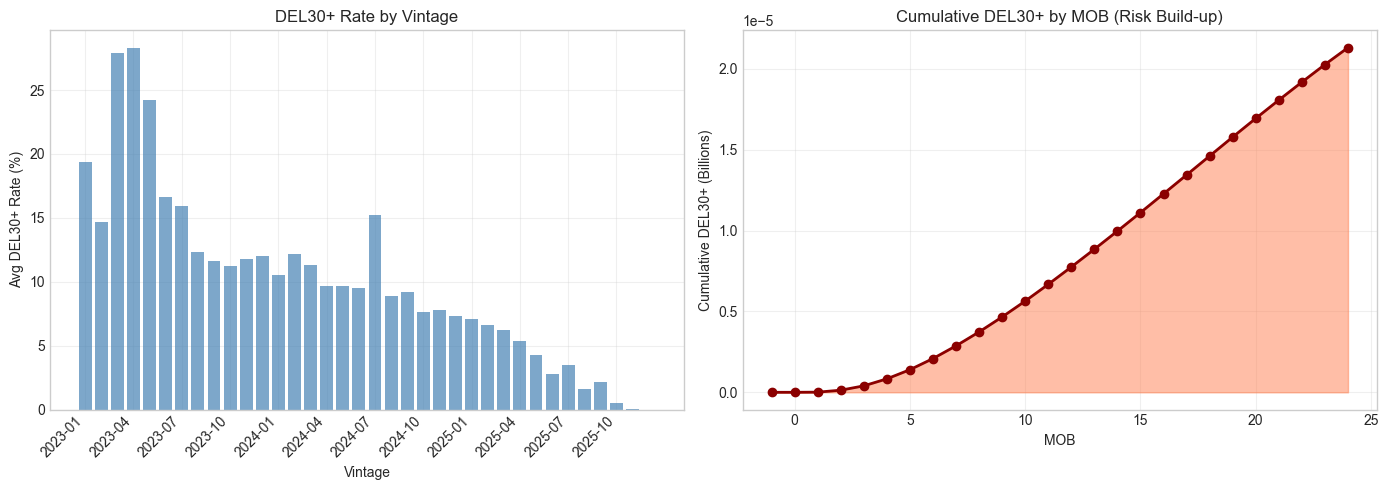

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

if len(df_backtest) > 0:
    vintage_trend = df_backtest.groupby('vintage').agg({'del30_rate': 'mean', 'DISB_TOTAL': 'sum'}).sort_index()
    axes[0].bar(range(len(vintage_trend)), vintage_trend['del30_rate'] * 100, alpha=0.7, color='steelblue')
    axes[0].set_xticks(range(0, len(vintage_trend), max(1, len(vintage_trend)//10)))
    axes[0].set_xticklabels([v.strftime('%Y-%m') if hasattr(v, 'strftime') else str(v)
                            for v in vintage_trend.index[::max(1, len(vintage_trend)//10)]], rotation=45, ha='right')
    axes[0].set_xlabel('Vintage')
    axes[0].set_ylabel('Avg DEL30+ Rate (%)')
    axes[0].set_title('DEL30+ Rate by Vintage')
    axes[0].grid(True, alpha=0.3)

    mob_cumulative = df_backtest.groupby('MOB')['DEL30_AMT'].sum().cumsum() / 1e9
    axes[1].fill_between(mob_cumulative.index, mob_cumulative.values, alpha=0.5, color='coral')
    axes[1].plot(mob_cumulative.index, mob_cumulative.values, 'o-', color='darkred', linewidth=2)
    axes[1].set_xlabel('MOB')
    axes[1].set_ylabel('Cumulative DEL30+ (Billions)')
    axes[1].set_title('Cumulative DEL30+ by MOB (Risk Build-up)')
    axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('outputs/del30_trends.png', dpi=150)
plt.show()

### 7.13 ⭐ So sánh Cohort cụ thể: Forecast từ MOB sớm (Early MOB Comparison)

**Vấn đề với so sánh hiện tại:**
- `forecast_all_vintages_partial_step` bắt đầu từ MOB cuối cùng của actual
- Forecast chỉ cover 1-2 MOBs → không thấy rõ impact của K

**Giải pháp:**
- Forecast từ MOB sớm (MOB=3) để thấy sự khác biệt thực sự
- So sánh: Actual vs Forecast (No K) vs Forecast (With K)

In [22]:
# ============================================================
# 7.13.1 Chọn cohort và cấu hình
# ============================================================
from src.rollrate.calibration_kmob import forecast_segment_partial_step

# Chọn cohort để so sánh (có thể thay đổi)
TARGET_VINTAGE = '2023-12'  # Cohort muốn so sánh
START_MOB = 3               # MOB bắt đầu forecast (sớm hơn để thấy rõ impact)

# Tìm cohort phù hợp trong actual_results
target_vintage_dt = pd.to_datetime(TARGET_VINTAGE)
matching_keys = [k for k in actual_results.keys() if k[2] == target_vintage_dt]

if not matching_keys:
    # Fallback: tìm cohort có nhiều MOB nhất
    best_key = max(actual_results.keys(), key=lambda k: len(actual_results[k]))
    print(f'⚠️ Không tìm thấy cohort {TARGET_VINTAGE}, sử dụng cohort có nhiều MOB nhất: {best_key}')
    matching_keys = [best_key]

# Chọn cohort đầu tiên match
selected_key = matching_keys[0]
product, score, vintage = selected_key
mob_dict = actual_results[selected_key]

print(f'\n📊 Cohort được chọn: {selected_key}')
print(f'   Product: {product}')
print(f'   Score: {score}')
print(f'   Vintage: {vintage}')
print(f'   MOBs có actual: {sorted(mob_dict.keys())}')
print(f'   Max actual MOB: {max(mob_dict.keys())}')
print(f'   Start MOB cho forecast: {START_MOB}')


📊 Cohort được chọn: ('T', 'A', Timestamp('2023-12-01 00:00:00'))
   Product: T
   Score: A
   Vintage: 2023-12-01 00:00:00
   MOBs có actual: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24]
   Max actual MOB: 24
   Start MOB cho forecast: 3


In [23]:
# ============================================================
# 7.13.2 Lấy DISB_TOTAL cho cohort này
# ============================================================
# DISB_TOTAL = tổng giải ngân ban đầu của cohort (không đổi theo MOB)
loan_disb_cohort = df_raw[
    (df_raw['PRODUCT_TYPE'] == product) &
    (df_raw['RISK_SCORE'] == score) &
    (df_raw[CFG['orig_date']] == vintage)
].groupby(CFG['loan'])[CFG['disb']].first().sum()

print(f'\n💰 DISB_TOTAL của cohort: {loan_disb_cohort:,.0f}')


💰 DISB_TOTAL của cohort: 14


In [24]:
# ============================================================
# 7.13.3 Forecast từ MOB sớm - WITH K và NO K
# ============================================================

# Kiểm tra START_MOB có trong actual không
if START_MOB not in mob_dict:
    available_mobs = sorted(mob_dict.keys())
    START_MOB = min(available_mobs)
    print(f'⚠️ MOB {START_MOB} không có actual, sử dụng MOB đầu tiên: {START_MOB}')

# Initial EAD từ MOB sớm (từ actual_results)
initial_ead = mob_dict[START_MOB].reindex(BUCKETS_CANON, fill_value=0.0)

# DEBUG: Kiểm tra initial_ead
print(f'\n🔍 DEBUG - Initial EAD tại MOB {START_MOB}:')
print(f'   Total EAD: {initial_ead.sum():,.0f}')
print(f'   DEL30+ buckets: {BUCKETS_30P}')
del30_amt_initial = sum(initial_ead.get(b, 0) for b in BUCKETS_30P)
print(f'   DEL30_AMT từ initial_ead: {del30_amt_initial:,.0f}')
print(f'   DEL30_PCT (nếu dùng loan_disb_cohort): {del30_amt_initial/loan_disb_cohort*100:.4f}%')

# K values cho No K (k=1.0 = Markov thuần túy)
k_no_k = {m: 1.0 for m in range(1, MAX_MOB + 1)}

# Forecast WITH K (sử dụng k_final_by_mob đã calibrate)
fc_with_k = forecast_segment_partial_step(
    matrices_by_mob=matrices_by_mob,
    parent_fallback=parent_fallback,
    product=product,
    score=score,
    start_mob=START_MOB,
    initial_ead=initial_ead,
    max_mob=MAX_MOB,
    k_by_mob=k_final_by_mob,
    states=BUCKETS_CANON
)

# Forecast NO K (k=1.0 = Markov thuần túy)
fc_no_k = forecast_segment_partial_step(
    matrices_by_mob=matrices_by_mob,
    parent_fallback=parent_fallback,
    product=product,
    score=score,
    start_mob=START_MOB,
    initial_ead=initial_ead,
    max_mob=MAX_MOB,
    k_by_mob=k_no_k,
    states=BUCKETS_CANON
)

print(f'\n✅ Forecast từ MOB {START_MOB} đến MOB {MAX_MOB}')
print(f'   Forecast (With K) MOBs: {sorted(fc_with_k.keys())}')
print(f'   Forecast (No K) MOBs: {sorted(fc_no_k.keys())}')

# DEBUG: Verify forecast tại START_MOB = initial_ead
print(f'\n🔍 VERIFY: Forecast tại START_MOB phải = initial_ead')
fc_start_no_k = fc_no_k[START_MOB]
fc_start_with_k = fc_with_k[START_MOB]
print(f'   initial_ead DEL30_AMT: {del30_amt_initial:,.0f}')
print(f'   fc_no_k[{START_MOB}] DEL30_AMT: {sum(fc_start_no_k.get(b, 0) for b in BUCKETS_30P):,.0f}')
print(f'   fc_with_k[{START_MOB}] DEL30_AMT: {sum(fc_start_with_k.get(b, 0) for b in BUCKETS_30P):,.0f}')


🔍 DEBUG - Initial EAD tại MOB 3:
   Total EAD: 14
   DEL30+ buckets: ['DPD30+', 'DPD60+', 'DPD90+', 'DPD120+', 'DPD180+', 'WRITEOFF']
   DEL30_AMT từ initial_ead: 0
   DEL30_PCT (nếu dùng loan_disb_cohort): 0.1791%

✅ Forecast từ MOB 3 đến MOB 24
   Forecast (With K) MOBs: [3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24]
   Forecast (No K) MOBs: [3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24]

🔍 VERIFY: Forecast tại START_MOB phải = initial_ead
   initial_ead DEL30_AMT: 0
   fc_no_k[3] DEL30_AMT: 0
   fc_with_k[3] DEL30_AMT: 0


In [25]:
# ============================================================
# 7.13.4 Tính DEL30+ Rate cho 3 đường: Actual, Forecast No K, Forecast With K
# ============================================================

def calc_del30_amt(ead_series):
    """Tính DEL30+ Amount từ EAD series (pandas Series)"""
    del30_amt = 0.0
    for bucket in BUCKETS_30P:
        if bucket in ead_series.index:
            del30_amt += ead_series[bucket]
    return del30_amt

def calc_del30_rate(ead_series, disb_total):
    """Tính DEL30+ Rate từ EAD series"""
    del30_amt = calc_del30_amt(ead_series)
    return del30_amt / disb_total if disb_total > 0 else 0

# ============================================================
# DEBUG: Kiểm tra data types và tìm cohort
# ============================================================
print(f'\n🔍 DEBUG - Data types:')
print(f'   product: {type(product).__name__} = {product}')
print(f'   score: {type(score).__name__} = {score}')
print(f'   vintage: {type(vintage).__name__} = {vintage}')
print(f'   df_lifecycle_final PRODUCT_TYPE dtype: {df_lifecycle_final["PRODUCT_TYPE"].dtype}')
print(f'   df_lifecycle_final RISK_SCORE dtype: {df_lifecycle_final["RISK_SCORE"].dtype}')
print(f'   df_lifecycle_final VINTAGE_DATE dtype: {df_lifecycle_final["VINTAGE_DATE"].dtype}')

# Convert to string để match với df_lifecycle_final
product_str = str(product)
score_str = str(score)
# Convert vintage to datetime để match
vintage_dt = pd.to_datetime(vintage)

print(f'\n   Converted: product_str={product_str}, score_str={score_str}, vintage_dt={vintage_dt}')

# ============================================================
# Actual DEL30+ Rate - LẤY TỪ df_lifecycle_final
# ============================================================
# Thử filter với vintage_dt trước
df_cohort_actual = df_lifecycle_final[
    (df_lifecycle_final['PRODUCT_TYPE'] == product_str) &
    (df_lifecycle_final['RISK_SCORE'] == score_str) &
    (df_lifecycle_final['VINTAGE_DATE'] == vintage_dt) &
    (df_lifecycle_final['IS_FORECAST'] == 0)
].copy()

# Nếu không tìm thấy, thử với vintage gốc
if len(df_cohort_actual) == 0:
    df_cohort_actual = df_lifecycle_final[
        (df_lifecycle_final['PRODUCT_TYPE'] == product_str) &
        (df_lifecycle_final['RISK_SCORE'] == score_str) &
        (df_lifecycle_final['VINTAGE_DATE'] == vintage) &
        (df_lifecycle_final['IS_FORECAST'] == 0)
    ].copy()

print(f'\n🔍 DEBUG - Filter results:')
print(f'   Số rows tìm được: {len(df_cohort_actual)}')

if len(df_cohort_actual) == 0:
    print(f'\n⚠️ KHÔNG TÌM THẤY DATA! Kiểm tra chi tiết:')
    mask_prod = df_lifecycle_final['PRODUCT_TYPE'] == product_str
    mask_score = df_lifecycle_final['RISK_SCORE'] == score_str
    mask_actual = df_lifecycle_final['IS_FORECAST'] == 0
    print(f'   Rows match PRODUCT_TYPE: {mask_prod.sum()}')
    print(f'   Rows match RISK_SCORE: {mask_score.sum()}')
    print(f'   Rows match IS_FORECAST=0: {mask_actual.sum()}')
    
    # Kiểm tra VINTAGE_DATE
    df_prod_score = df_lifecycle_final[mask_prod & mask_score]
    unique_vintages = df_prod_score['VINTAGE_DATE'].unique()
    print(f'   Unique VINTAGE_DATE for this product/score: {len(unique_vintages)}')
    print(f'   Sample values: {list(unique_vintages[:5])}')
    print(f'   Sample types: {[type(v).__name__ for v in unique_vintages[:3]]}')
    raise ValueError('Không tìm thấy actual data cho cohort này!')

# ============================================================
# Lấy Actual DEL30_PCT từ df_lifecycle_final (đã tính đúng)
# ============================================================
actual_del30 = dict(zip(df_cohort_actual['MOB'], df_cohort_actual['DEL30_PCT']))
actual_del30_amt = dict(zip(df_cohort_actual['MOB'], df_cohort_actual['DEL30_AMT']))
disb_total_from_df = df_cohort_actual['DISB_TOTAL'].iloc[0]

print(f'\n✅ Actual data từ df_lifecycle_final:')
print(f'   Số MOBs: {len(actual_del30)}')
print(f'   MOB range: {min(actual_del30.keys())} - {max(actual_del30.keys())}')
print(f'   DISB_TOTAL: {disb_total_from_df:,.0f}')
print(f'   loan_disb_cohort (từ 7.13.2): {loan_disb_cohort:,.0f}')
print(f'   Chênh lệch: {abs(disb_total_from_df - loan_disb_cohort):,.0f}')

# In sample DEL30_PCT và DEL30_AMT để verify
for mob in [3, 6, 12, 18, 24]:
    if mob in actual_del30:
        pct = actual_del30[mob]
        amt = actual_del30_amt[mob]
        print(f'   MOB {mob}: DEL30_AMT={amt:,.0f}, DEL30_PCT={pct*100:.2f}%')

# ============================================================
# Forecast (No K) DEL30+ Rate - Tính từ forecast EAD
# ============================================================
fc_no_k_del30 = {}
fc_no_k_del30_amt = {}
for mob, ead_series in fc_no_k.items():
    fc_no_k_del30_amt[mob] = calc_del30_amt(ead_series)
    fc_no_k_del30[mob] = calc_del30_rate(ead_series, disb_total_from_df)

# ============================================================
# Forecast (With K) DEL30+ Rate - Tính từ forecast EAD
# ============================================================
fc_with_k_del30 = {}
fc_with_k_del30_amt = {}
for mob, ead_series in fc_with_k.items():
    fc_with_k_del30_amt[mob] = calc_del30_amt(ead_series)
    fc_with_k_del30[mob] = calc_del30_rate(ead_series, disb_total_from_df)

print(f'\n✅ Forecast data:')
print(f'   Forecast (No K) MOBs: {sorted(fc_no_k_del30.keys())}')
print(f'   Forecast (With K) MOBs: {sorted(fc_with_k_del30.keys())}')

# ============================================================
# So sánh Actual vs Forecast tại MOB bắt đầu (START_MOB)
# ============================================================
print(f'\n🔍 VERIFY tại START_MOB={START_MOB}:')
if START_MOB in actual_del30 and START_MOB in fc_no_k_del30:
    print(f'   Actual DEL30_PCT: {actual_del30[START_MOB]*100:.4f}%')
    print(f'   FC No K DEL30_PCT: {fc_no_k_del30[START_MOB]*100:.4f}%')
    print(f'   FC With K DEL30_PCT: {fc_with_k_del30[START_MOB]*100:.4f}%')
    print(f'   (Tại START_MOB, cả 3 phải BẰNG NHAU vì dùng cùng initial_ead)')

# ============================================================
# Bảng so sánh chi tiết
# ============================================================
print('\n📈 DEL30+ Rate (%) theo MOB:')
print(f'{"MOB":>5} | {"Actual":>10} | {"FC No K":>10} | {"FC With K":>10} | {"K value":>8} | {"Error NoK":>10} | {"Error WithK":>10}')
print('-' * 90)

all_mobs = sorted(set(actual_del30.keys()) | set(fc_no_k_del30.keys()))
for mob in all_mobs:
    actual_val = actual_del30.get(mob, None)
    no_k_val = fc_no_k_del30.get(mob, None)
    with_k_val = fc_with_k_del30.get(mob, None)
    k_val = k_final_by_mob.get(mob, 1.0)
    
    actual_str = f'{actual_val*100:.2f}%' if actual_val is not None else '-'
    no_k_str = f'{no_k_val*100:.2f}%' if no_k_val is not None else '-'
    with_k_str = f'{with_k_val*100:.2f}%' if with_k_val is not None else '-'
    k_str = f'{k_val:.4f}'
    
    # Tính error
    if actual_val is not None and no_k_val is not None:
        err_no_k = (no_k_val - actual_val) * 100
        err_no_k_str = f'{err_no_k:+.2f}pp'
    else:
        err_no_k_str = '-'
    
    if actual_val is not None and with_k_val is not None:
        err_with_k = (with_k_val - actual_val) * 100
        err_with_k_str = f'{err_with_k:+.2f}pp'
    else:
        err_with_k_str = '-'
    
    print(f'{mob:>5} | {actual_str:>10} | {no_k_str:>10} | {with_k_str:>10} | {k_str:>8} | {err_no_k_str:>10} | {err_with_k_str:>10}')

print(f'\n💰 DISB_TOTAL: {disb_total_from_df:,.0f}')
print(f'📊 Công thức: DEL30_PCT = DEL30_AMT / DISB_TOTAL')


🔍 DEBUG - Data types:
   product: str = T
   score: str = A
   vintage: Timestamp = 2023-12-01 00:00:00
   df_lifecycle_final PRODUCT_TYPE dtype: object
   df_lifecycle_final RISK_SCORE dtype: object
   df_lifecycle_final VINTAGE_DATE dtype: datetime64[ns]

   Converted: product_str=T, score_str=A, vintage_dt=2023-12-01 00:00:00

🔍 DEBUG - Filter results:
   Số rows tìm được: 25

✅ Actual data từ df_lifecycle_final:
   Số MOBs: 25
   MOB range: 0 - 24
   DISB_TOTAL: 14
   loan_disb_cohort (từ 7.13.2): 14
   Chênh lệch: 0
   MOB 3: DEL30_AMT=0, DEL30_PCT=0.18%
   MOB 6: DEL30_AMT=0, DEL30_PCT=1.71%
   MOB 12: DEL30_AMT=1, DEL30_PCT=5.35%
   MOB 18: DEL30_AMT=1, DEL30_PCT=7.77%
   MOB 24: DEL30_AMT=1, DEL30_PCT=9.25%

✅ Forecast data:
   Forecast (No K) MOBs: [3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24]
   Forecast (With K) MOBs: [3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24]

🔍 VERIFY tại START_MOB=3:
   Actual DEL

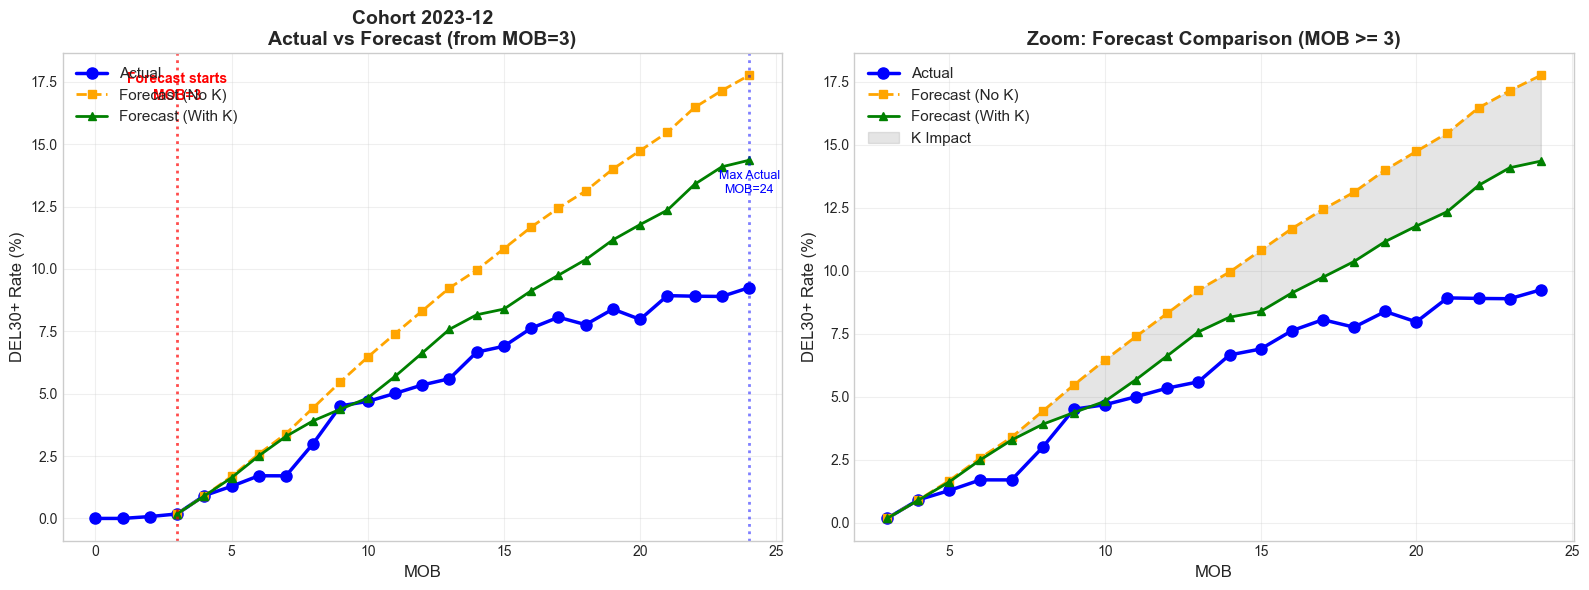


✅ Chart saved to outputs/cohort_early_mob_comparison.png


In [26]:
# ============================================================
# 7.13.5 Chart: So sánh 3 đường
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- Chart 1: Full comparison ---
ax1 = axes[0]

# Actual (chỉ vẽ các MOB có actual)
actual_mobs = sorted(actual_del30.keys())
actual_vals = [actual_del30[m] * 100 for m in actual_mobs]
ax1.plot(actual_mobs, actual_vals, 'o-', label='Actual', linewidth=2.5, markersize=8, color='blue')

# Forecast No K (từ START_MOB)
fc_no_k_mobs = sorted([m for m in fc_no_k_del30.keys() if m >= START_MOB])
fc_no_k_vals = [fc_no_k_del30[m] * 100 for m in fc_no_k_mobs]
ax1.plot(fc_no_k_mobs, fc_no_k_vals, 's--', label='Forecast (No K)', linewidth=2, markersize=6, color='orange')

# Forecast With K (từ START_MOB)
fc_with_k_mobs = sorted([m for m in fc_with_k_del30.keys() if m >= START_MOB])
fc_with_k_vals = [fc_with_k_del30[m] * 100 for m in fc_with_k_mobs]
ax1.plot(fc_with_k_mobs, fc_with_k_vals, '^-', label='Forecast (With K)', linewidth=2, markersize=6, color='green')

# Mark forecast start point
ax1.axvline(x=START_MOB, color='red', linestyle=':', linewidth=2, alpha=0.7)
ax1.annotate(f'Forecast starts\nMOB={START_MOB}', xy=(START_MOB, ax1.get_ylim()[1]*0.9),
             fontsize=10, color='red', ha='center', fontweight='bold')

# Mark max actual MOB
max_actual_mob = max(actual_del30.keys())
ax1.axvline(x=max_actual_mob, color='blue', linestyle=':', linewidth=2, alpha=0.5)
ax1.annotate(f'Max Actual\nMOB={max_actual_mob}', xy=(max_actual_mob, ax1.get_ylim()[1]*0.7),
             fontsize=9, color='blue', ha='center')

ax1.set_xlabel('MOB', fontsize=12)
ax1.set_ylabel('DEL30+ Rate (%)', fontsize=12)
ax1.set_title(f'Cohort {vintage.strftime("%Y-%m") if hasattr(vintage, "strftime") else vintage}\n'
              f'Actual vs Forecast (from MOB={START_MOB})', fontsize=14, fontweight='bold')
ax1.legend(fontsize=11, loc='upper left')
ax1.grid(True, alpha=0.3)

# --- Chart 2: Zoom vào phần forecast (sau START_MOB) ---
ax2 = axes[1]

# Chỉ vẽ từ START_MOB trở đi
actual_mobs_zoom = [m for m in actual_mobs if m >= START_MOB]
actual_vals_zoom = [actual_del30[m] * 100 for m in actual_mobs_zoom]

if actual_mobs_zoom:
    ax2.plot(actual_mobs_zoom, actual_vals_zoom, 'o-', label='Actual', linewidth=2.5, markersize=8, color='blue')
ax2.plot(fc_no_k_mobs, fc_no_k_vals, 's--', label='Forecast (No K)', linewidth=2, markersize=6, color='orange')
ax2.plot(fc_with_k_mobs, fc_with_k_vals, '^-', label='Forecast (With K)', linewidth=2, markersize=6, color='green')

# Shade difference between No K and With K
common_mobs = sorted(set(fc_no_k_mobs) & set(fc_with_k_mobs))
if len(common_mobs) > 1:
    no_k_common = [fc_no_k_del30[m] * 100 for m in common_mobs]
    with_k_common = [fc_with_k_del30[m] * 100 for m in common_mobs]
    ax2.fill_between(common_mobs, no_k_common, with_k_common, alpha=0.2, color='gray', label='K Impact')

ax2.set_xlabel('MOB', fontsize=12)
ax2.set_ylabel('DEL30+ Rate (%)', fontsize=12)
ax2.set_title(f'Zoom: Forecast Comparison (MOB >= {START_MOB})', fontsize=14, fontweight='bold')
ax2.legend(fontsize=11)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('outputs/cohort_early_mob_comparison.png', dpi=150)
plt.show()

print(f'\n✅ Chart saved to outputs/cohort_early_mob_comparison.png')

In [27]:
# ============================================================
# 7.13.6 Tính MAE/MAPE để đánh giá accuracy
# ============================================================

# Chỉ so sánh tại các MOB có cả actual và forecast
common_mobs_eval = sorted(set(actual_del30.keys()) & set(fc_no_k_del30.keys()) & set(fc_with_k_del30.keys()))
# Loại bỏ START_MOB vì đó là điểm bắt đầu (giống nhau)
common_mobs_eval = [m for m in common_mobs_eval if m > START_MOB]

if len(common_mobs_eval) > 0:
    actual_arr = np.array([actual_del30[m] for m in common_mobs_eval])
    no_k_arr = np.array([fc_no_k_del30[m] for m in common_mobs_eval])
    with_k_arr = np.array([fc_with_k_del30[m] for m in common_mobs_eval])
    
    # Error arrays (forecast - actual)
    error_no_k = (no_k_arr - actual_arr) * 100  # in percentage points
    error_with_k = (with_k_arr - actual_arr) * 100
    
    # Absolute error arrays
    abs_error_no_k = np.abs(error_no_k)
    abs_error_with_k = np.abs(error_with_k)
    
    # MAE (percentage points)
    mae_no_k = np.mean(abs_error_no_k)
    mae_with_k = np.mean(abs_error_with_k)
    
    # MAPE (%)
    nonzero = actual_arr > 0.0001
    if nonzero.sum() > 0:
        mape_no_k = np.mean(np.abs((actual_arr[nonzero] - no_k_arr[nonzero]) / actual_arr[nonzero])) * 100
        mape_with_k = np.mean(np.abs((actual_arr[nonzero] - with_k_arr[nonzero]) / actual_arr[nonzero])) * 100
        
        # APE by MOB for chart
        ape_no_k_by_mob = np.abs((actual_arr[nonzero] - no_k_arr[nonzero]) / actual_arr[nonzero]) * 100
        ape_with_k_by_mob = np.abs((actual_arr[nonzero] - with_k_arr[nonzero]) / actual_arr[nonzero]) * 100
        mobs_for_ape = [common_mobs_eval[i] for i in range(len(common_mobs_eval)) if nonzero[i]]
    else:
        mape_no_k = mape_with_k = np.nan
        ape_no_k_by_mob = ape_with_k_by_mob = []
        mobs_for_ape = []
    
    print('\n' + '='*60)
    print('📊 ACCURACY METRICS (MOBs có cả Actual và Forecast)')
    print('='*60)
    print(f'\nMOBs được so sánh: {common_mobs_eval}')
    print(f'\n--- MAE (Mean Absolute Error) ---')
    print(f'   Forecast (No K):   {mae_no_k:.4f} pp')
    print(f'   Forecast (With K): {mae_with_k:.4f} pp')
    
    if mae_no_k > mae_with_k:
        improvement = (mae_no_k - mae_with_k) / mae_no_k * 100
        print(f'   ✅ With K tốt hơn {improvement:.1f}%')
    else:
        degradation = (mae_with_k - mae_no_k) / mae_no_k * 100 if mae_no_k > 0 else 0
        print(f'   ⚠️ No K tốt hơn {degradation:.1f}%')
    
    print(f'\n--- MAPE (Mean Absolute Percentage Error) ---')
    print(f'   Forecast (No K):   {mape_no_k:.2f}%')
    print(f'   Forecast (With K): {mape_with_k:.2f}%')
    
    if mape_no_k > mape_with_k:
        improvement = (mape_no_k - mape_with_k) / mape_no_k * 100
        print(f'   ✅ With K tốt hơn {improvement:.1f}%')
    else:
        degradation = (mape_with_k - mape_no_k) / mape_no_k * 100 if mape_no_k > 0 else 0
        print(f'   ⚠️ No K tốt hơn {degradation:.1f}%')
    
    print('='*60)
else:
    print('\n⚠️ Không có MOB nào có cả Actual và Forecast để so sánh!')
    print('   Điều này có nghĩa là cohort này chưa có đủ actual data sau START_MOB.')
    error_no_k = error_with_k = abs_error_no_k = abs_error_with_k = np.array([])
    mae_no_k = mae_with_k = mape_no_k = mape_with_k = np.nan


📊 ACCURACY METRICS (MOBs có cả Actual và Forecast)

MOBs được so sánh: [4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24]

--- MAE (Mean Absolute Error) ---
   Forecast (No K):   3.8275 pp
   Forecast (With K): 1.9727 pp
   ✅ With K tốt hơn 48.5%

--- MAPE (Mean Absolute Percentage Error) ---
   Forecast (No K):   58.77%
   Forecast (With K): 32.28%
   ✅ With K tốt hơn 45.1%


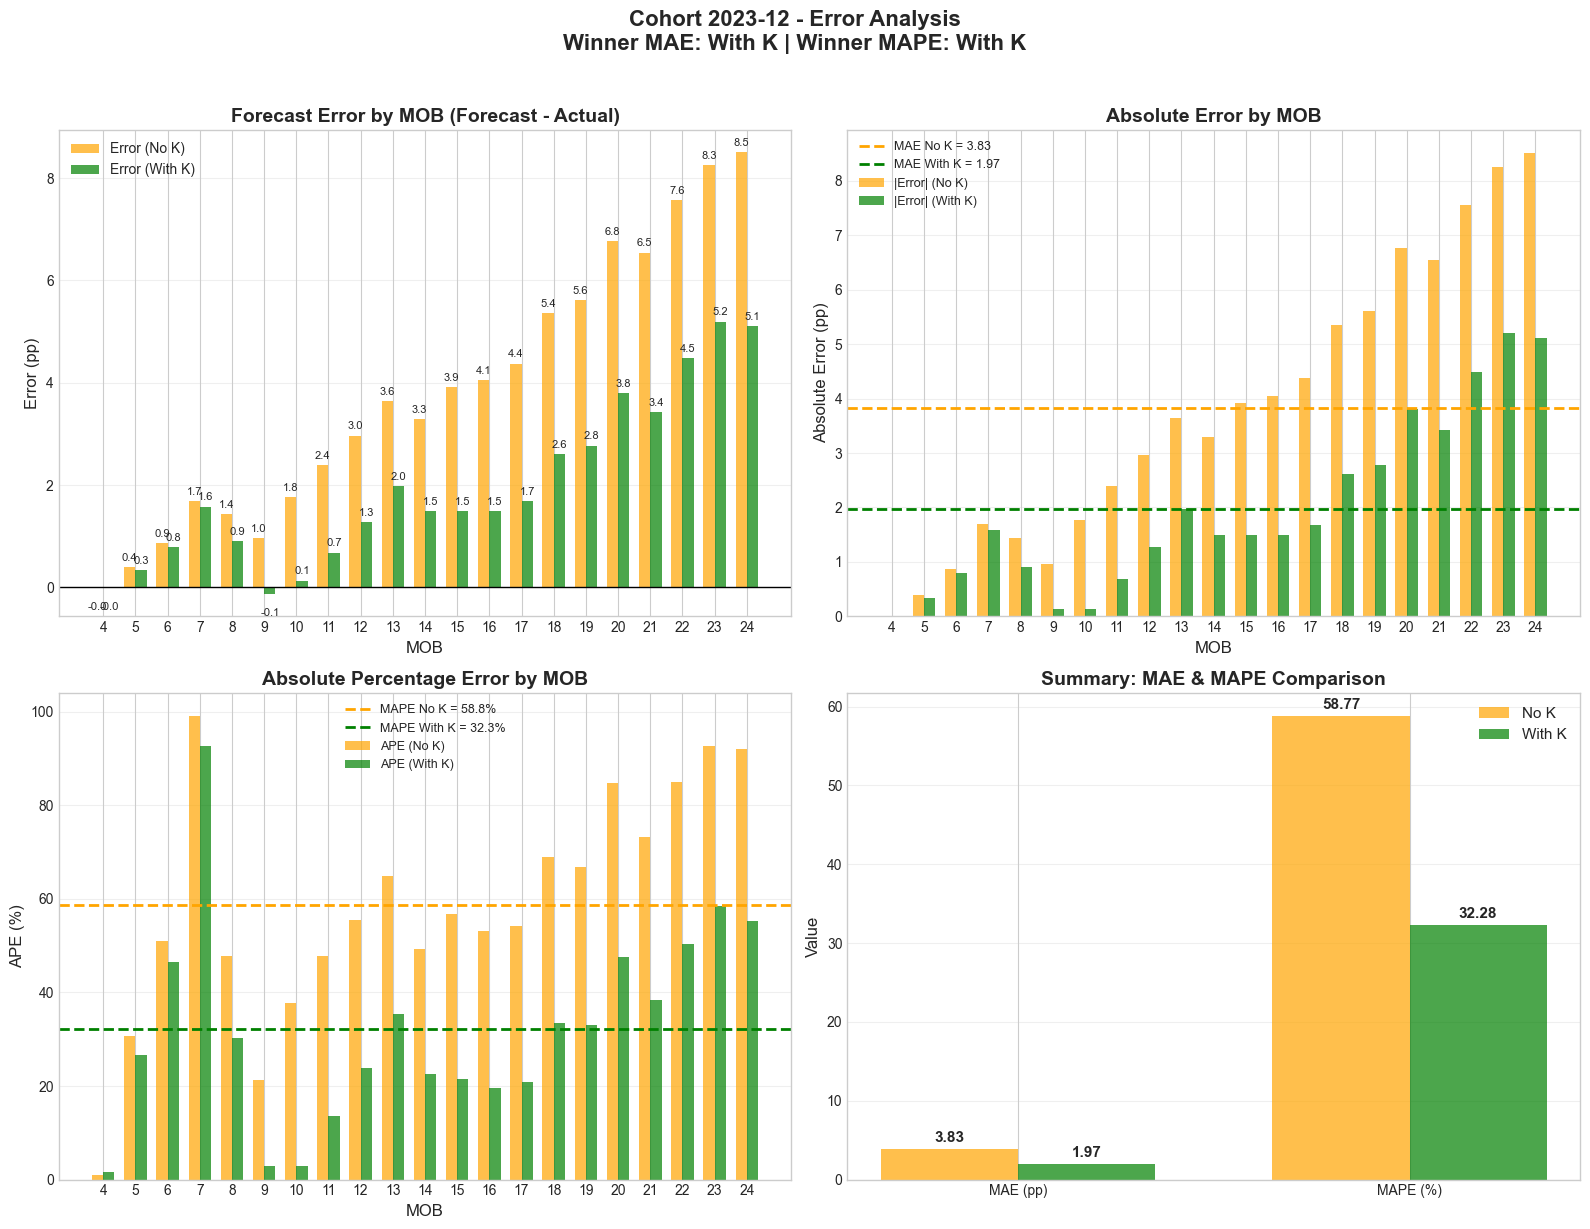


✅ Chart saved to outputs/cohort_mae_mape_analysis.png


In [28]:
# ============================================================
# 7.13.6b Chart: MAE và MAPE theo MOB
# ============================================================

if len(common_mobs_eval) > 0:
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    
    # --- Chart 1: Error by MOB (Forecast - Actual) ---
    ax1 = axes[0, 0]
    x = np.arange(len(common_mobs_eval))
    width = 0.35
    
    bars1 = ax1.bar(x - width/2, error_no_k, width, label='Error (No K)', color='orange', alpha=0.7)
    bars2 = ax1.bar(x + width/2, error_with_k, width, label='Error (With K)', color='green', alpha=0.7)
    ax1.axhline(y=0, color='black', linestyle='-', linewidth=1)
    ax1.set_xlabel('MOB', fontsize=12)
    ax1.set_ylabel('Error (pp)', fontsize=12)
    ax1.set_title('Forecast Error by MOB (Forecast - Actual)', fontsize=14, fontweight='bold')
    ax1.set_xticks(x)
    ax1.set_xticklabels(common_mobs_eval)
    ax1.legend(fontsize=10)
    ax1.grid(True, alpha=0.3, axis='y')
    
    # Add value labels
    for bar in bars1:
        height = bar.get_height()
        ax1.annotate(f'{height:.1f}', xy=(bar.get_x() + bar.get_width()/2, height),
                     xytext=(0, 3 if height >= 0 else -10), textcoords='offset points',
                     ha='center', va='bottom' if height >= 0 else 'top', fontsize=8)
    for bar in bars2:
        height = bar.get_height()
        ax1.annotate(f'{height:.1f}', xy=(bar.get_x() + bar.get_width()/2, height),
                     xytext=(0, 3 if height >= 0 else -10), textcoords='offset points',
                     ha='center', va='bottom' if height >= 0 else 'top', fontsize=8)
    
    # --- Chart 2: Absolute Error by MOB ---
    ax2 = axes[0, 1]
    ax2.bar(x - width/2, abs_error_no_k, width, label='|Error| (No K)', color='orange', alpha=0.7)
    ax2.bar(x + width/2, abs_error_with_k, width, label='|Error| (With K)', color='green', alpha=0.7)
    ax2.axhline(y=mae_no_k, color='orange', linestyle='--', linewidth=2, label=f'MAE No K = {mae_no_k:.2f}')
    ax2.axhline(y=mae_with_k, color='green', linestyle='--', linewidth=2, label=f'MAE With K = {mae_with_k:.2f}')
    ax2.set_xlabel('MOB', fontsize=12)
    ax2.set_ylabel('Absolute Error (pp)', fontsize=12)
    ax2.set_title('Absolute Error by MOB', fontsize=14, fontweight='bold')
    ax2.set_xticks(x)
    ax2.set_xticklabels(common_mobs_eval)
    ax2.legend(fontsize=9)
    ax2.grid(True, alpha=0.3, axis='y')
    
    # --- Chart 3: APE by MOB (if available) ---
    ax3 = axes[1, 0]
    if len(mobs_for_ape) > 0:
        x_ape = np.arange(len(mobs_for_ape))
        ax3.bar(x_ape - width/2, ape_no_k_by_mob, width, label='APE (No K)', color='orange', alpha=0.7)
        ax3.bar(x_ape + width/2, ape_with_k_by_mob, width, label='APE (With K)', color='green', alpha=0.7)
        ax3.axhline(y=mape_no_k, color='orange', linestyle='--', linewidth=2, label=f'MAPE No K = {mape_no_k:.1f}%')
        ax3.axhline(y=mape_with_k, color='green', linestyle='--', linewidth=2, label=f'MAPE With K = {mape_with_k:.1f}%')
        ax3.set_xlabel('MOB', fontsize=12)
        ax3.set_ylabel('APE (%)', fontsize=12)
        ax3.set_title('Absolute Percentage Error by MOB', fontsize=14, fontweight='bold')
        ax3.set_xticks(x_ape)
        ax3.set_xticklabels(mobs_for_ape)
        ax3.legend(fontsize=9)
        ax3.grid(True, alpha=0.3, axis='y')
    else:
        ax3.text(0.5, 0.5, 'No data for APE calculation', ha='center', va='center', fontsize=14)
        ax3.set_title('Absolute Percentage Error by MOB', fontsize=14, fontweight='bold')
    
    # --- Chart 4: Summary comparison ---
    ax4 = axes[1, 1]
    metrics = ['MAE (pp)', 'MAPE (%)']
    no_k_values = [mae_no_k, mape_no_k]
    with_k_values = [mae_with_k, mape_with_k]
    
    x_metrics = np.arange(len(metrics))
    width_metrics = 0.35
    
    bars_no_k = ax4.bar(x_metrics - width_metrics/2, no_k_values, width_metrics, label='No K', color='orange', alpha=0.7)
    bars_with_k = ax4.bar(x_metrics + width_metrics/2, with_k_values, width_metrics, label='With K', color='green', alpha=0.7)
    
    ax4.set_ylabel('Value', fontsize=12)
    ax4.set_title('Summary: MAE & MAPE Comparison', fontsize=14, fontweight='bold')
    ax4.set_xticks(x_metrics)
    ax4.set_xticklabels(metrics)
    ax4.legend(fontsize=11)
    ax4.grid(True, alpha=0.3, axis='y')
    
    # Add value labels
    for bar in bars_no_k:
        height = bar.get_height()
        ax4.annotate(f'{height:.2f}', xy=(bar.get_x() + bar.get_width()/2, height),
                     xytext=(0, 3), textcoords='offset points', ha='center', va='bottom', fontsize=11, fontweight='bold')
    for bar in bars_with_k:
        height = bar.get_height()
        ax4.annotate(f'{height:.2f}', xy=(bar.get_x() + bar.get_width()/2, height),
                     xytext=(0, 3), textcoords='offset points', ha='center', va='bottom', fontsize=11, fontweight='bold')
    
    # Add winner annotation
    winner_mae = 'With K' if mae_with_k < mae_no_k else 'No K'
    winner_mape = 'With K' if mape_with_k < mape_no_k else 'No K'
    
    plt.suptitle(f'Cohort {vintage.strftime("%Y-%m") if hasattr(vintage, "strftime") else vintage} - Error Analysis\n'
                 f'Winner MAE: {winner_mae} | Winner MAPE: {winner_mape}', 
                 fontsize=16, fontweight='bold', y=1.02)
    
    plt.tight_layout()
    plt.savefig('outputs/cohort_mae_mape_analysis.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    print(f'\n✅ Chart saved to outputs/cohort_mae_mape_analysis.png')
else:
    print('\n⚠️ Không đủ data để vẽ chart MAE/MAPE')

In [29]:
# ============================================================
# 7.13.7 Giải thích K values
# ============================================================

print('\n' + '='*60)
print('📖 GIẢI THÍCH K VALUES')
print('='*60)

print(f'\n🔹 Công thức partial-step:')
print(f'   v_{{m+1}} = v_m + k_m × (v_hat - v_m)')
print(f'   Trong đó:')
print(f'   - v_m: State vector tại MOB m')
print(f'   - v_hat: Markov forecast = v_m × P_m')
print(f'   - k_m: K factor tại MOB m (đã clip trong [0, 1])')

print(f'\n🔹 Ý nghĩa K:')
print(f'   - K = 1.0: Full Markov step (No K) → v_{{m+1}} = v_hat')
print(f'   - K < 1.0: Partial step → v_{{m+1}} nằm giữa v_m và v_hat')
print(f'   - K < 1 nghĩa là model over-estimates risk → K scale DOWN forecast')

print(f'\n🔹 K values được sử dụng (MOB {START_MOB} → {MAX_MOB}):')
k_used = {m: k_final_by_mob.get(m, 1.0) for m in range(START_MOB, MAX_MOB + 1)}
k_values_list = list(k_used.values())
print(f'   Min K: {min(k_values_list):.4f}')
print(f'   Max K: {max(k_values_list):.4f}')
print(f'   Mean K: {np.mean(k_values_list):.4f}')

if np.mean(k_values_list) < 0.95:
    print(f'\n   ⚠️ Mean K < 0.95 → Forecast (With K) sẽ THẤP hơn Forecast (No K)')
elif np.mean(k_values_list) > 1.05:
    print(f'\n   ⚠️ Mean K > 1.05 → Forecast (With K) sẽ CAO hơn Forecast (No K)')
else:
    print(f'\n   ℹ️ Mean K ~ 1.0 → Forecast (With K) và (No K) gần như giống nhau')

print('='*60)


📖 GIẢI THÍCH K VALUES

🔹 Công thức partial-step:
   v_{m+1} = v_m + k_m × (v_hat - v_m)
   Trong đó:
   - v_m: State vector tại MOB m
   - v_hat: Markov forecast = v_m × P_m
   - k_m: K factor tại MOB m (đã clip trong [0, 1])

🔹 Ý nghĩa K:
   - K = 1.0: Full Markov step (No K) → v_{m+1} = v_hat
   - K < 1.0: Partial step → v_{m+1} nằm giữa v_m và v_hat
   - K < 1 nghĩa là model over-estimates risk → K scale DOWN forecast

🔹 K values được sử dụng (MOB 3 → 24):
   Min K: 0.2590
   Max K: 1.0000
   Mean K: 0.7948

   ⚠️ Mean K < 0.95 → Forecast (With K) sẽ THẤP hơn Forecast (No K)


---
## All outputs saved to `outputs/` folder

Charts ready for management presentation!